# Custom Fonts

In [ ]:
!apt-get -qq install -y fonts-roboto 2>/dev/null
!apt-get -qq install -y fonts-firacode 2>/dev/null
!apt-get -qq install -y fonts-jetbrains-mono 2>/dev/null
!apt-get -qq install -y fonts-sourcecode-pro 2>/dev/null

import glob, matplotlib.pyplot as plt, matplotlib.font_manager as fm

MAGIC = (b'\x00\x01\x00\x00', b'OTTO', b'true', b'ttcf')

def is_font(p):
    with open(p, 'rb') as f:
        return f.read(4) in MAGIC

import os
paths = [p for d in ('/usr/share/fonts', os.path.expanduser('~/.local/share/fonts'))
         for p in glob.glob(f'{d}/**/*.[ot]tf', recursive=True) if is_font(p)]
for p in paths:
    try:
        fm.fontManager.addfont(p)
    except (NotImplementedError, RuntimeError):  # bitmap fonts
        pass

for fam in ["Fira Code", "JetBrains Mono", "Source Code Pro"]:
    faces = [(f.weight, f.style) for f in fm.fontManager.ttflist if f.name == fam]
    print(fam, faces)

# Set plotting parameters
plt.rcParams.update({
    "font.family": 'JetBrains Mono',
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.dpi": 600
})

Selecting previously unselected package fonts-roboto-unhinted.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../fonts-roboto-unhinted_2%3a0~20170802-3_all.deb ...
Unpacking fonts-roboto-unhinted (2:0~20170802-3) ...
Selecting previously unselected package fonts-roboto.
Preparing to unpack .../fonts-roboto_2%3a0~20170802-3_all.deb ...
Unpacking fonts-roboto (2:0~20170802-3) ...
Setting up fonts-roboto-unhinted (2:0~20170802-3) ...
Setting up fonts-roboto (2:0~20170802-3) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Selecting previously unselected package fonts-firacode.
(Reading database ... 118452 files and directories currently installed.)
Preparing to unpack .../fonts-firacode_6.2-1_all.deb ...
Unpacking fonts-firacode (6.2-1) ...
Setting up fonts-firacode (6.2-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Selecting previously unselected package fonts-jetbrains-mono.
(Reading database ... 118478 fil

# Setup

In [ ]:
from pathlib import Path

REPO = Path("/opt/developer/iitm-projects/steel-ss")
FIGS = REPO / "figs"

#Steel Production Routes

/tmp/ipykernel_1146/3328671842.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.5)
/tmp/ipykernel_1146/3328671842.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

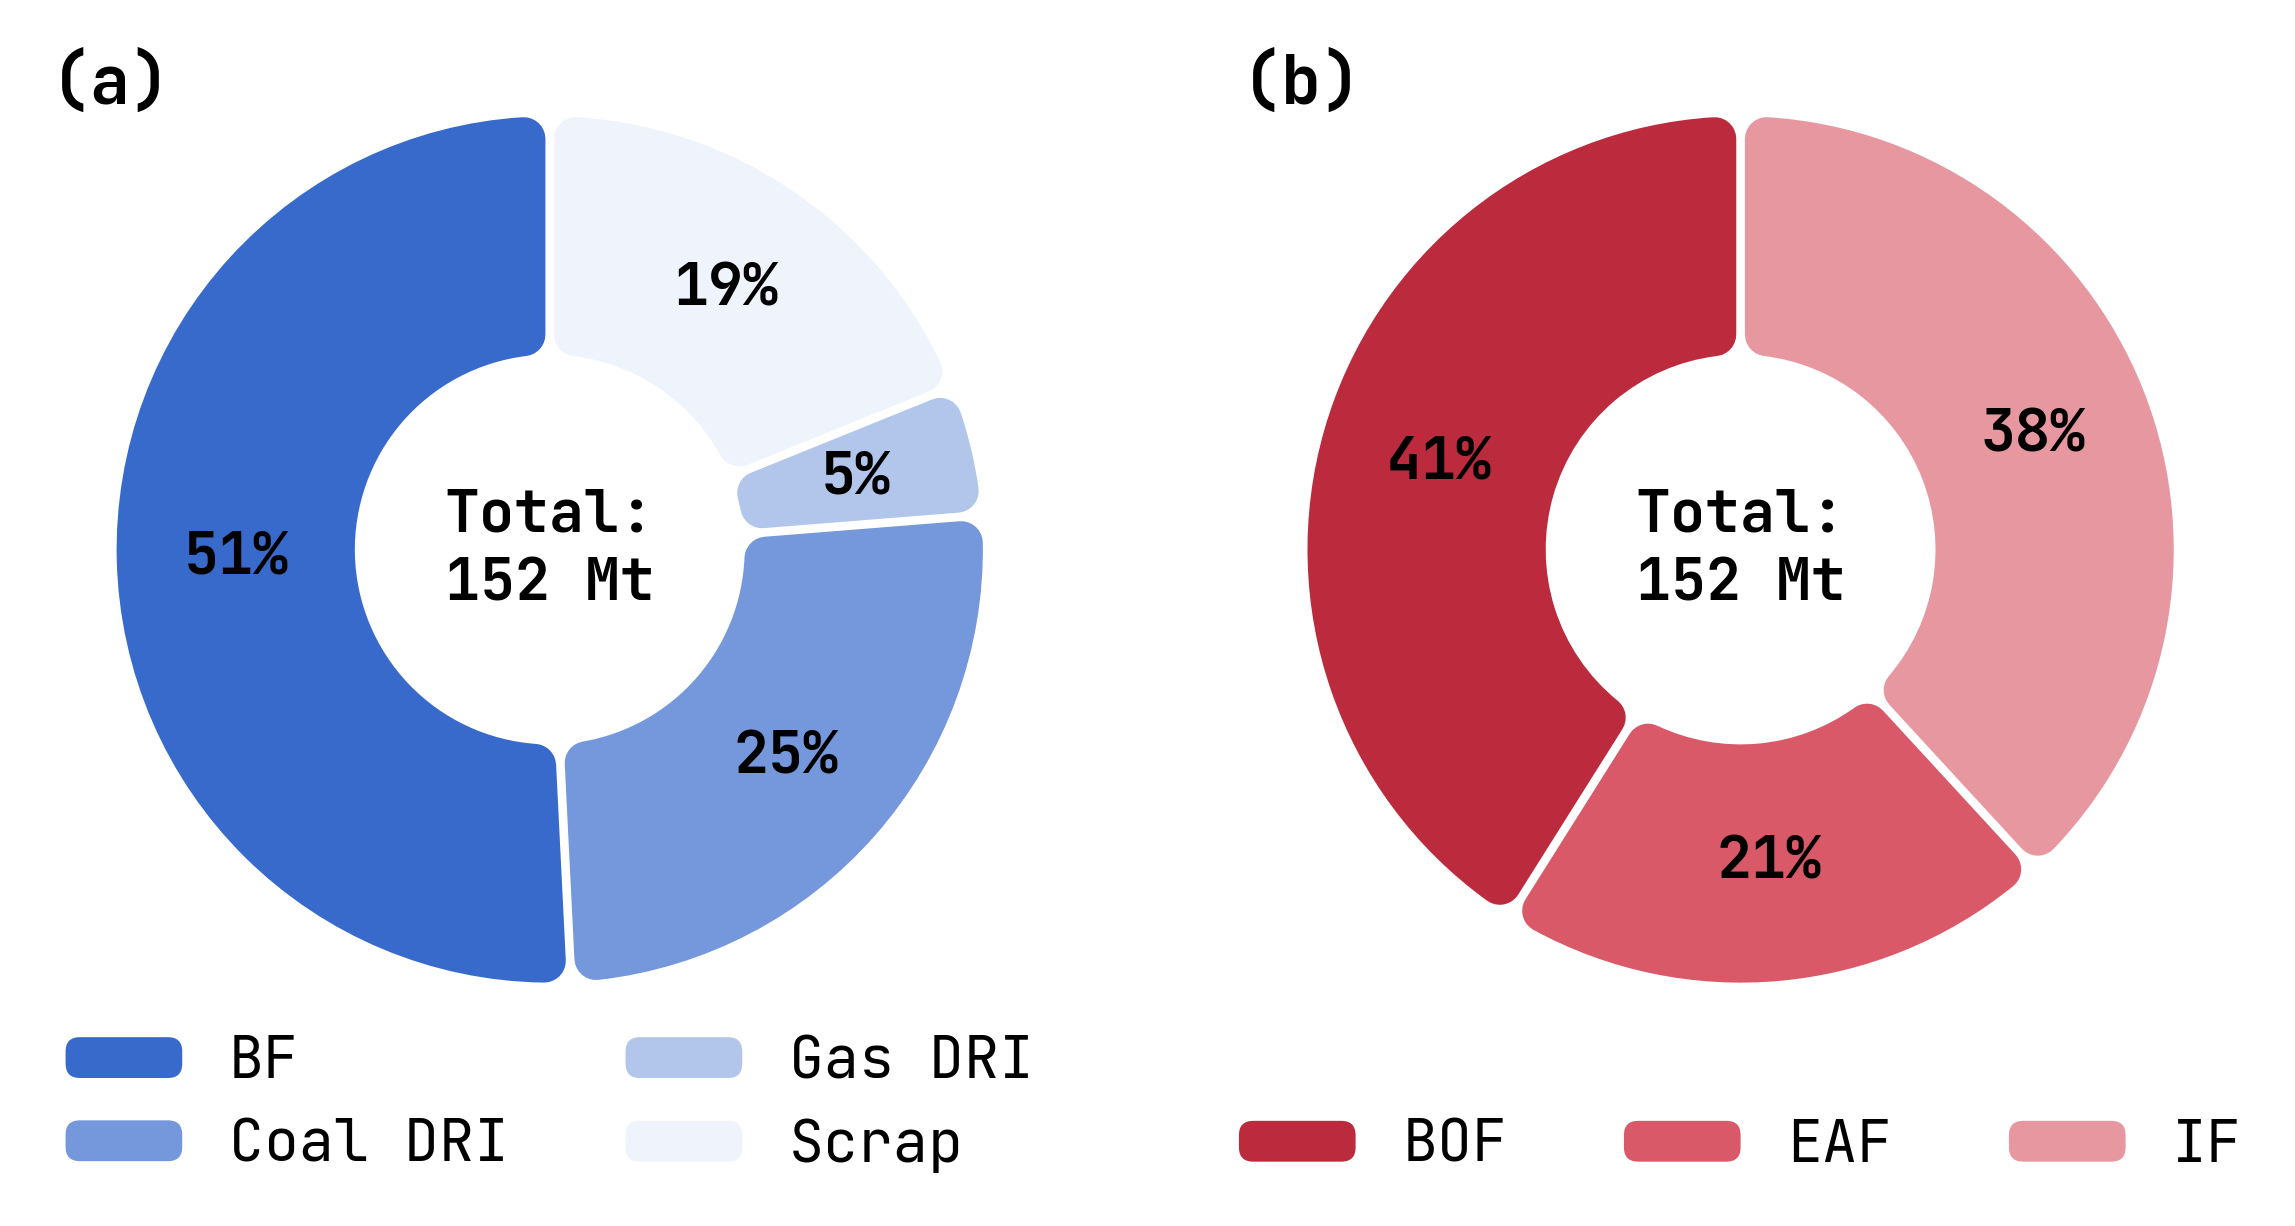

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch, FancyBboxPatch
from matplotlib.legend_handler import HandlerPatch

# Figure settings
FIGSIZE = (10, 4.5)
R_OUT = 1.00            # outer radius
R_IN = 0.45             # inner radius
GAP = 0.02              # gap width in data units
ROUND_R = 0.05          # corner radius
START_ANGLE = 90

# Font sizes - all set to 16
LABEL_FONT = 14
CENTER_FONT = 14
AB_FONT = 16
LEGEND_FONT = 14

# Data for metallic inputs
metallic_labels = ['BF', 'Coal DRI', 'Gas DRI', 'Scrap']
metallic_values = [77.2, 38.72, 7.38, 28.7]
metallic_colors = ["#386acb", "#7597db", "#b2c5eb", "#eff3fb"]

# Data for production routes
route_labels = ['BOF', 'EAF', 'IF']
route_values = [62.47, 31.62, 58.06]
route_colors = ["#bc2b3d", "#d95968", "#e797a0"]


def pts_per_data_unit(ax):
    fig = ax.figure
    fig.canvas.draw()
    bbox = ax.get_window_extent()
    x0, x1 = ax.get_xlim()
    return bbox.width / (x1 - x0) * 72.0 / fig.dpi


def _reverse(verts):
    return verts[::-1]


def parallel_gap_section(th1, th2, ri, ro, d):
    a_out = np.degrees(np.arcsin(np.clip(d / ro, -1, 1)))
    a_in = np.degrees(np.arcsin(np.clip(d / ri, -1, 1)))

    if th2 - th1 <= 2 * a_in:
        raise ValueError("section too narrow for this gap")

    outer = Path.arc(th1 + a_out, th2 - a_out).vertices * ro
    inner = _reverse(Path.arc(th1 + a_in, th2 - a_in).vertices) * ri

    verts = np.vstack([outer, inner, [[0, 0]]])
    codes = ([Path.MOVETO] + [Path.CURVE4] * (len(outer) - 1)
             + [Path.LINETO] + [Path.CURVE4] * (len(inner) - 1)
             + [Path.CLOSEPOLY])
    return Path(verts, codes)


class HandlerRoundedPatch(HandlerPatch):
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                        width, height, fontsize, trans):
        p = FancyBboxPatch(
            (xdescent, ydescent), width, height,
            boxstyle="round,pad=0,rounding_size=" + str(height * 0.35),
            facecolor=orig_handle.get_facecolor(),
            edgecolor=orig_handle.get_edgecolor(),
            linewidth=orig_handle.get_linewidth(),
            mutation_aspect=1,
        )
        p.set_transform(trans)
        return [p]


def donut(ax, values, colors, labels, ncol=None):
    # Setup axes
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.axis('off')

    # Calculate linewidth and offsets
    lw_data = 2 * ROUND_R
    lw = lw_data * pts_per_data_unit(ax)
    ro = R_OUT - ROUND_R
    ri = R_IN + ROUND_R
    d = GAP / 2 + ROUND_R

    total = sum(values)
    start = START_ANGLE
    handles = []

    for value, color, label in zip(values, colors, labels):
        span = value / total * 360.0
        p = parallel_gap_section(start, start + span, ri, ro, d)

        ax.add_patch(PathPatch(p, facecolor=color, edgecolor=color,
                               linewidth=lw, joinstyle='round'))
        handles.append(Patch(facecolor=color))

        # Percentage label
        mid = np.deg2rad(start + span / 2)
        r_text = (R_IN + R_OUT) / 2
        ax.text(r_text * np.cos(mid), r_text * np.sin(mid), f'{value/total:.0%}',
                ha='center', va='center', fontsize=LABEL_FONT, weight='bold')
        start += span

    # Center text - two lines
    ax.text(0, 0.08, 'Total:', ha='center', va='center', fontsize=CENTER_FONT, weight='bold')
    ax.text(0, -0.08, '152 Mt', ha='center', va='center', fontsize=CENTER_FONT, weight='bold')

    # Legend
    if ncol is None:
        ncol = len(labels)

    ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
              ncol=ncol, frameon=False, fontsize=LEGEND_FONT,
              handler_map={h: HandlerRoundedPatch() for h in handles})


# Plot with tight layout
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, gridspec_kw={'wspace': 0.05})
plt.tight_layout(pad=1.5)

# Metallic inputs
donut(axes[0], metallic_values, metallic_colors, metallic_labels, ncol=2)
axes[0].text(0.02, 0.98, '(a)', transform=axes[0].transAxes,
             ha='left', va='top', fontsize=AB_FONT, weight='bold')

# Production routes
donut(axes[1], route_values, route_colors, route_labels, ncol=3)
axes[1].text(0.02, 0.98, '(b)', transform=axes[1].transAxes,
             ha='left', va='top', fontsize=AB_FONT, weight='bold')

# Save
plt.tight_layout()
fig.savefig(FIGS / "current-route.png", dpi=300, bbox_inches='tight', facecolor="white")

# Feasibility and Synergy

Detected 4 data blocks


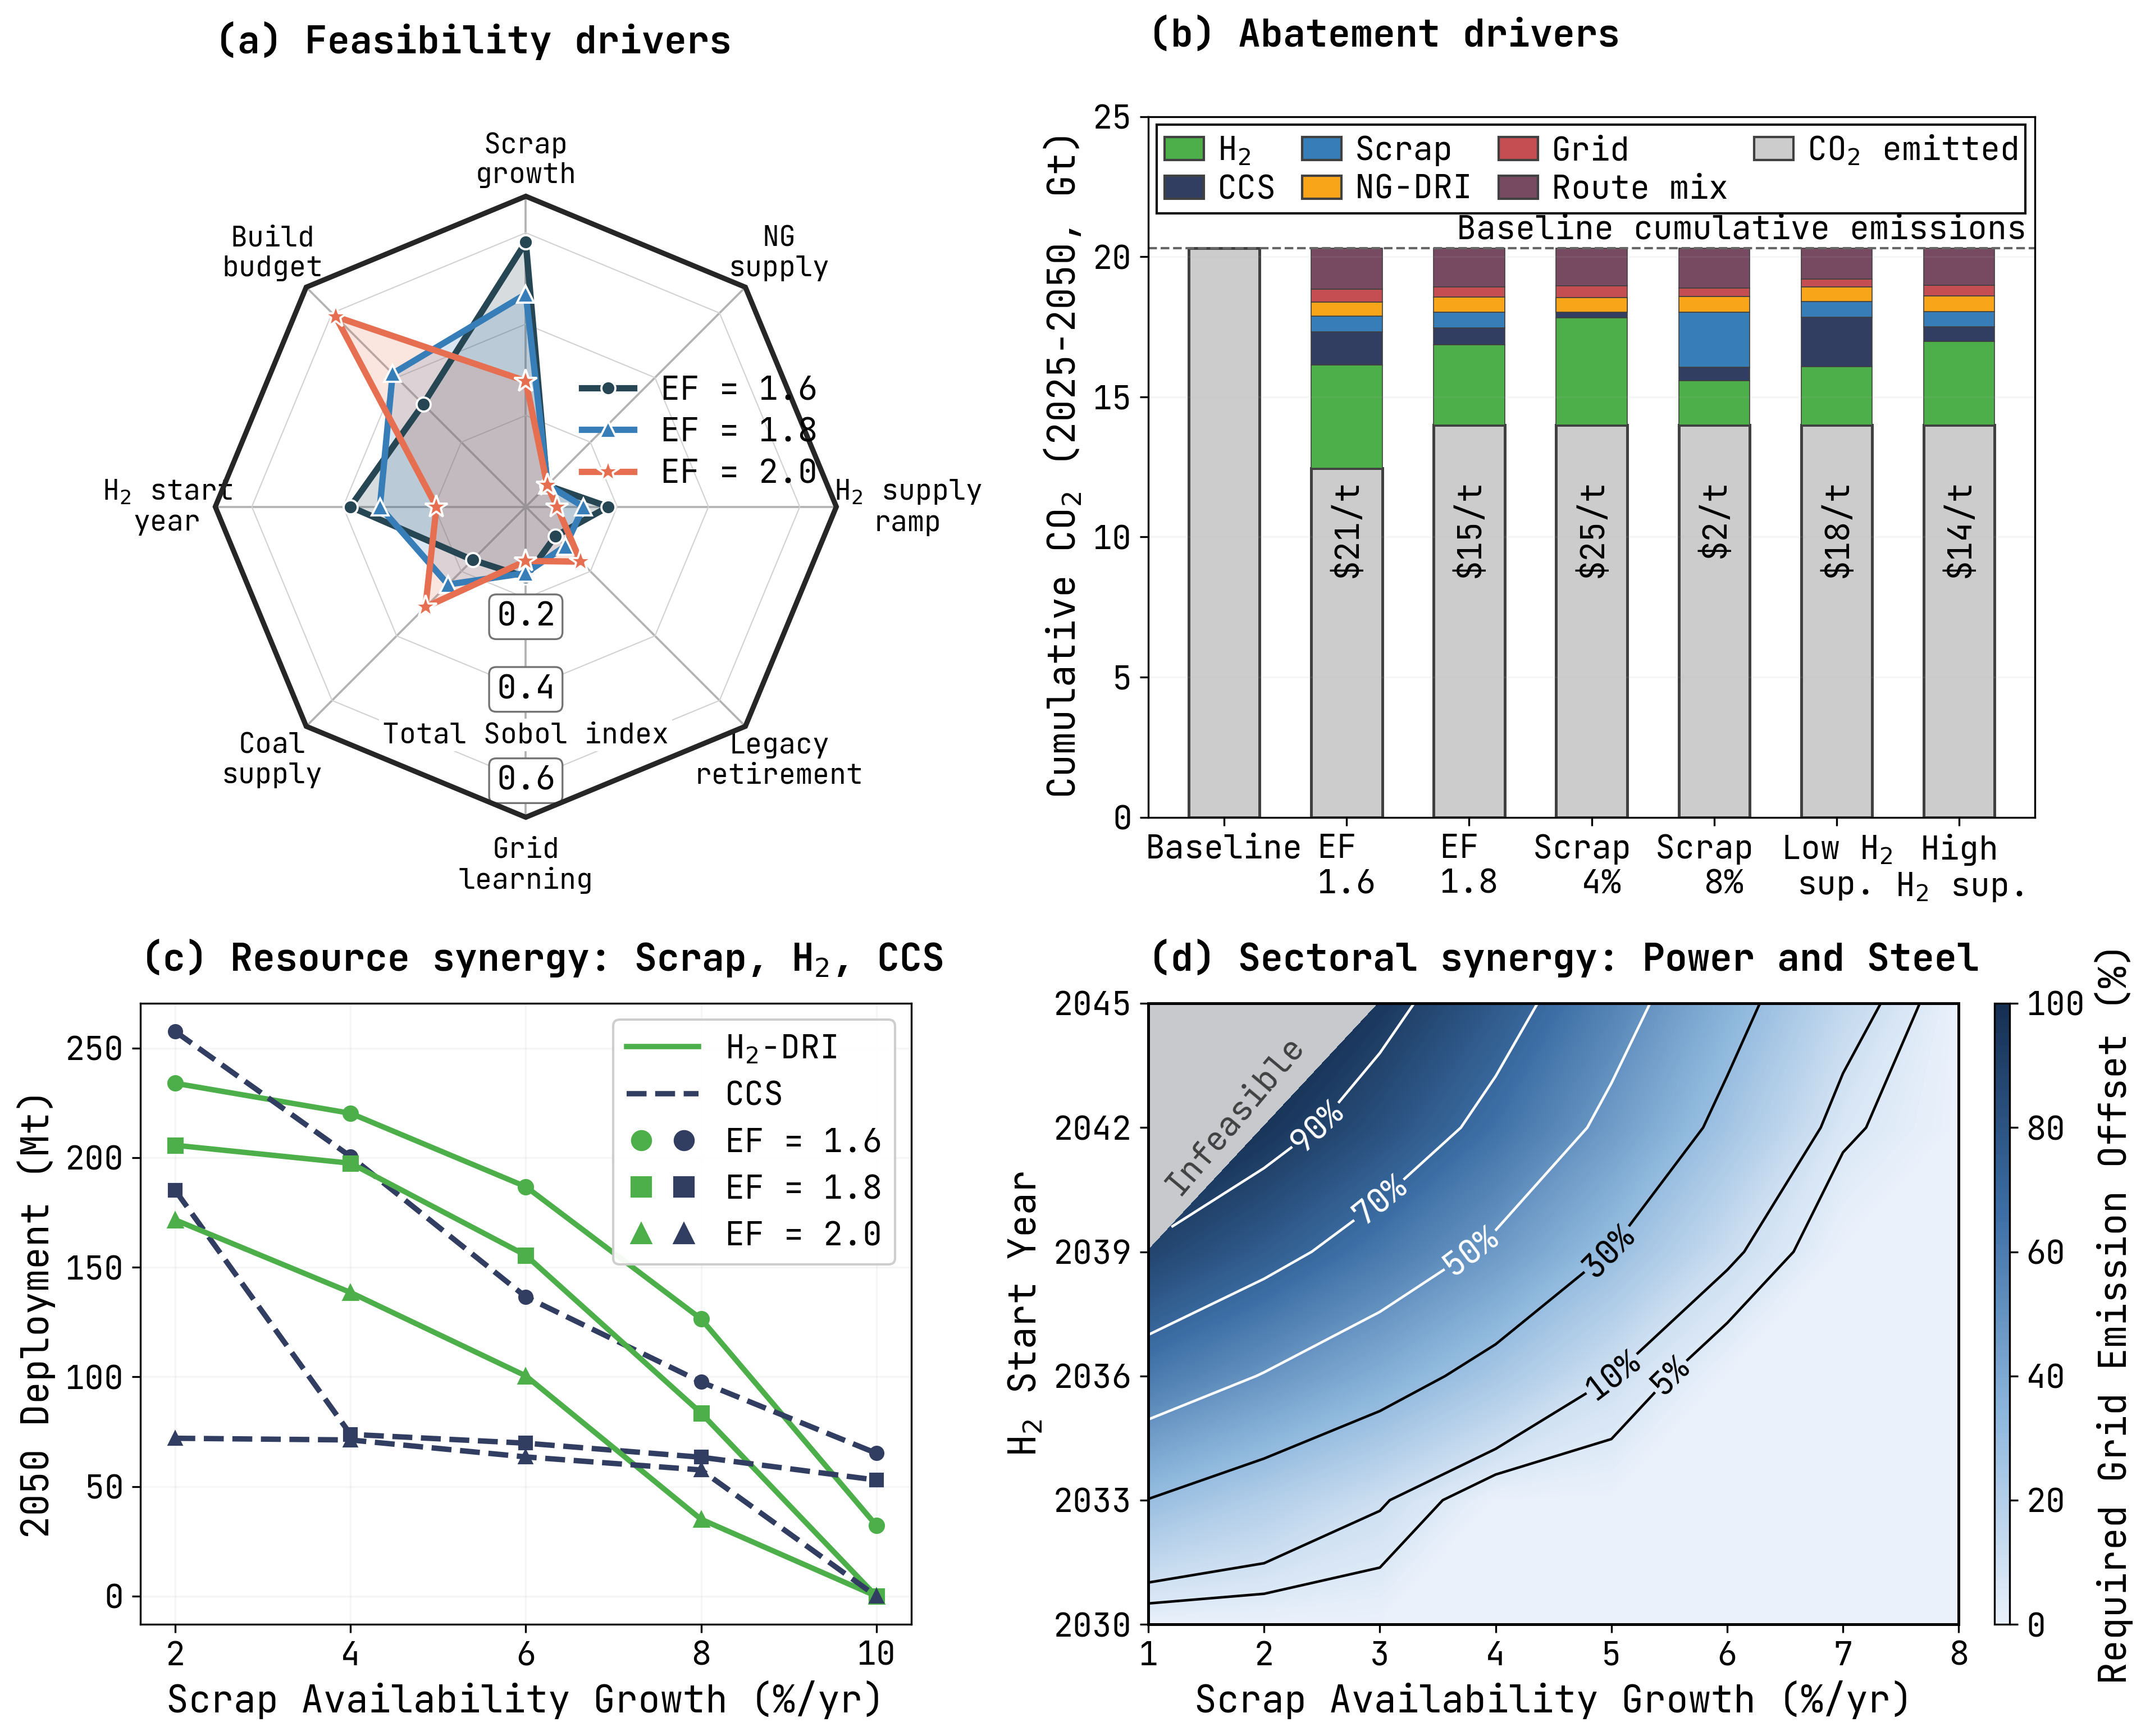

written: fig_synergy.png, fig_synergy.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import subprocess, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Patch, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D, ScaledTranslation
from matplotlib.legend_handler import HandlerTuple

subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-jetbrains-mono"], capture_output=True)

MAGIC = (b'\x00\x01\x00\x00', b'OTTO', b'true', b'ttcf')

def is_font(p):
    with open(p, "rb") as f: return f.read(4) in MAGIC

for p in glob.glob("/usr/share/fonts/**/*.[ot]tf", recursive=True):
    if is_font(p): fm.fontManager.addfont(p)

# ============================================================
# FONTS
# ============================================================

FONT = "JetBrains Mono"

FS_BASE = 14
FS_AXIS = 16
FS_TICK = 14
FS_TITLE = 16
FS_LEGEND = 14
FS_SMALL = 14
FS_LABEL = 14
FS_RADAR_LABEL = 12
FS_RADAR_INDEX = 12

FW_NORMAL = "normal"
FW_BOLD = "bold"

plt.rcParams.update({
    "font.family": FONT,
    "font.size": FS_BASE,
    "axes.labelsize": FS_AXIS,
    "axes.labelweight": FW_NORMAL,
    "axes.titlesize": FS_TITLE,
    "axes.titleweight": FW_BOLD,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "figure.dpi": 300
})

# ============================================================
# DATA
# ============================================================

SHEET_ID = "1kZBxStjMw9qw_mJVffyv22tlFHJ0RAJ8_puvGVnJLOc"
GID = "2099428840"
url = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"
raw = pd.read_csv(url, header=None)

def split_blocks(raw):
    empty, blocks, start = raw.isna().all(axis=0), [], None

    for j in range(raw.shape[1]):
        if not empty.iloc[j] and start is None:
            start = j
        elif empty.iloc[j] and start is not None:
            block = raw.iloc[:, start:j].dropna(how="all").copy()
            if not block.empty:
                block.columns = block.iloc[0].astype(str).str.strip()
                blocks.append(block.iloc[1:].reset_index(drop=True).dropna(how="all"))
            start = None

    if start is not None:
        block = raw.iloc[:, start:].dropna(how="all").copy()
        if not block.empty:
            block.columns = block.iloc[0].astype(str).str.strip()
            blocks.append(block.iloc[1:].reset_index(drop=True).dropna(how="all"))

    return blocks

blocks = split_blocks(raw)
print(f"Detected {len(blocks)} data blocks")

if len(blocks) != 4:
    raise ValueError(f"Expected 4 data blocks separated by empty columns, but found {len(blocks)}.")

df_sobol, df_abatement, df_scrap, df_grid = blocks

# ============================================================
# COLORS
# ============================================================

GREEN = "#4daf4a"
NAVY = "#313e61"
BLUE = "#377eb8"
PURPLE = "#774a62"
AMBER = "#f9a51a"
RED = "#c44e52"

# ============================================================
# LABELS AND SETTINGS
# ============================================================

SOBOL_NICE = {
    "build_cap": "Build\nbudget",
    "scrap_rate": "Scrap\ngrowth",
    "h2_start": "H$_2$ start\nyear",
    "ccoal": "Coal\nsupply",
    "theta_grid_target": "Grid\nlearning",
    "legacy": "Legacy\nretirement",
    "ramp": "H$_2$ supply\nramp",
    "ng": "NG\nsupply"
}

DRIVER_TO_AXIS = {
    "Build budget": "build_cap",
    "Scrap growth": "scrap_rate",
    "H2 start year": "h2_start",
    "Coking-coal supply": "ccoal",
    "Grid learning": "theta_grid_target",
    "Legacy retirement": "legacy",
    "H2 supply ramp": "ramp",
    "NG supply": "ng"
}

SOBOL_EFS = [1.6, 1.8, 2.0]
SOBOL_COLORS = {1.6: "#264653", 1.8: "#377eb8", 2.0: "#e76f51"}
SOBOL_MARKERS = {1.6: "o", 1.8: "^", 2.0: "*"}
SOBOL_MSIZES = {1.6: 6, 1.8: 7, 2.0: 10}

# ============================================================
# RADAR
# ============================================================

def radar_factory(num_vars, frame="polygon"):
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            if path._interpolation_steps > 1: path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):
        name = "radar"
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location("N")

        def fill(self, *args, closed=True, **kwargs):
            return super().fill(*args, closed=closed, **kwargs)

        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines: self._close_line(line)
            return lines

        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]: line.set_data(np.append(x, x[0]), np.append(y, y[0]))

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            if frame == "circle": return Circle((0.5, 0.5), 0.5)
            return RegularPolygon((0.5, 0.5), num_vars, radius=0.5, edgecolor="k")

        def _gen_axes_spines(self):
            if frame == "circle": return super()._gen_axes_spines()
            spine = Spine(self, "circle", Path.unit_regular_polygon(num_vars))
            spine.set_transform(Affine2D().scale(0.5).translate(0.5, 0.5) + self.transAxes)
            return {"polar": spine}

    register_projection(RadarAxes)
    return theta

RADAR_THETA = radar_factory(8, frame="polygon")

# ============================================================
# PANEL A: FEASIBILITY DRIVERS
# ============================================================

def panel_sobol(fig, ax):
    df = df_sobol.copy()
    df["avg_emi"] = pd.to_numeric(df["avg_emi"], errors="coerce")
    df["S_T"] = pd.to_numeric(df["S_T"], errors="coerce")

    piv = df.pivot(index="driver", columns="avg_emi", values="S_T")
    piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]
    names = [SOBOL_NICE[DRIVER_TO_AXIS[d]] for d in piv.index]

    ax.set_ylim(0, 0.68)
    ax.set_rgrids([0.2, 0.4, 0.6], labels=["0.2", "0.4", "0.6"],
                  angle=180, fontsize=FS_SMALL, color="black")

    for k, lbl in enumerate(ax.get_yticklabels()):
        lbl.set_rotation(0)
        lbl.set_ha("center")
        lbl.set_va("center")
        lbl.set_zorder(20)
        lbl.set_bbox(dict(facecolor="white", edgecolor="0.45", linewidth=0.8,
                          boxstyle="round,pad=0.22"))
        if k == 0:
            lbl.set_transform(lbl.get_transform() +
                              ScaledTranslation(0, -8/72, fig.dpi_scale_trans))

    ax.yaxis.grid(color="0.82", lw=0.5)
    ax.xaxis.grid(color="0.7", lw=0.9)
    ax.spines["polar"].set_color("0.15")
    ax.spines["polar"].set_linewidth(2.2)

    for ef in SOBOL_EFS:
        vals = piv[ef].values
        ax.plot(RADAR_THETA, vals, color=SOBOL_COLORS[ef], lw=2.7,
                marker=SOBOL_MARKERS[ef], ms=SOBOL_MSIZES[ef],
                markerfacecolor=SOBOL_COLORS[ef], markeredgecolor="white",
                markeredgewidth=0.9, label=f"EF = {ef}",
                zorder=3 + SOBOL_EFS.index(ef), clip_on=False)
        ax.fill(RADAR_THETA, vals, color=SOBOL_COLORS[ef], alpha=0.18, zorder=2)

    ax.set_varlabels(names)
    ax.tick_params(axis="x", pad=10)

    for lbl in ax.get_xticklabels():
        lbl.set_fontsize(FS_RADAR_LABEL)

        if lbl.get_text() == "Scrap\ngrowth":
            lbl.set_transform(lbl.get_transform() +
                              ScaledTranslation(0, -5/72, fig.dpi_scale_trans))

        elif lbl.get_text() == "H$_2$ supply\nramp":
            lbl.set_transform(lbl.get_transform() +
                              ScaledTranslation(10/72, 0, fig.dpi_scale_trans))

    leg = ax.legend(loc="center", bbox_to_anchor=(0.78, 0.62),
                    fontsize=FS_SMALL, frameon=False, labelspacing=0.35,
                    handlelength=1.6)
    leg.set_zorder(40)

    ax.text(np.pi, 0.50, "Total Sobol index", ha="center", va="center",
            fontsize=FS_RADAR_INDEX, color="black", zorder=25,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5))

# ============================================================
# PANEL B: ABATEMENT DRIVERS
# ============================================================

def panel_abatement(ax):
    SLICES = [
        ("H$_2$", "H2 (Gt)", GREEN),
        ("CCS", "CCS (Gt)", NAVY),
        ("Scrap", "Scrap (Gt)", BLUE),
        ("NG-DRI", "NG-DRI (Gt)", AMBER),
        ("Grid", "Grid (Gt)", RED),
        ("Route mix", "Route mix (Gt)", PURPLE)
    ]

    EMITTED_FC = "0.8"
    df = df_abatement.copy()

    numeric_cols = ["CO2 emitted (Gt)", "H2 (Gt)", "CCS (Gt)", "Scrap (Gt)",
                    "NG-DRI (Gt)", "Grid (Gt)", "Route mix (Gt)",
                    "Abatement cost ($/tCO2)"]

    for col in numeric_cols:
        if col in df.columns: df[col] = pd.to_numeric(df[col], errors="coerce")

    base_cum = float(df.loc[df.Scenario == "Baseline", "CO2 emitted (Gt)"].iloc[0])
    x, width = np.arange(len(df)), 0.58

    for i, row in df.iterrows():
        emitted = row["CO2 emitted (Gt)"]

        ax.bar(i, emitted, width, facecolor=EMITTED_FC,
               edgecolor="0.25", linewidth=1.2)

        bottom = emitted

        for _, col, color in SLICES:
            v = row[col]
            if pd.isna(v) or v == 0: continue

            ax.bar(i, v, width, bottom=bottom, color=color,
                   edgecolor="0.25", linewidth=0.4,
                   hatch="//" if v < 0 else None)
            bottom += v

        cost = row["Abatement cost ($/tCO2)"]
        if pd.notna(cost):
            ax.text(i, base_cum * 1.08 * 0.55, f"${float(cost):.0f}/t",
                    ha="center", va="top", fontsize=FS_LABEL,
                    rotation=90, color="black")

    ax.axhline(base_cum, color="0.4", linestyle="--", linewidth=1)
    ax.text(len(df)-0.45, base_cum+0.35, "Baseline cumulative emissions",
            fontsize=FS_LABEL, color="black", ha="right")

    labels = {
        "RL": "Low H$_2$\nsup.",
        "RH": "High\nH$_2$ sup.",
        "S4": "Scrap \n 4%",
        "S8": "Scrap \n 8%",
        "EF1.6": "EF \n1.6",
        "EF1.8": "EF \n1.8"
    }

    ax.set_xticks(x)
    ax.set_xticklabels([labels.get(s, s) for s in df.Scenario], fontsize=FS_TICK)
    ax.set_ylabel("Cumulative CO$_2$ (2025-2050, Gt)")
    ax.grid(axis="y", alpha=0.1)
    ax.set_ylim(0, 25)
    ax.set_yticks(np.arange(0, 26, 5))

    handles = [Patch(facecolor=color, edgecolor="0.25", label=label)
               for label, _, color in SLICES]
    handles.append(Patch(facecolor=EMITTED_FC, edgecolor="0.25",
                         label="CO$_2$ emitted"))

    ax.legend(handles=handles, loc="upper left", fontsize=FS_LEGEND, ncol=4,
              frameon=True, framealpha=0.95, facecolor="white",
              edgecolor="black", fancybox=False, borderpad=0.25,
              labelspacing=0.25, columnspacing=0.8, handlelength=1.2,
              handletextpad=0.4, borderaxespad=0.25)

# ============================================================
# PANEL C: SCRAP, H2 AND CCS
# ============================================================

def panel_scrap_effect(ax):
    df = df_scrap.copy().rename(columns={
        "Scrap growth (%/yr)": "Scrap",
        "H2 DRI Capacity (Mt/yr)": "H2",
        "CCS 2050 (MtCO2)": "CCS"
    })

    df["EF"] = pd.to_numeric(df["EF"], errors="coerce")
    df["Scrap"] = pd.to_numeric(df["Scrap"], errors="coerce")
    df["Feasible"] = df["H2"].astype(str).str.upper().str.strip() != "X"

    for c in ("H2", "CCS"):
        df[c] = pd.to_numeric(df[c], errors="coerce")

    markers = {1.6: "o", 1.8: "s", 2.0: "^"}

    for ef in sorted(df.EF.dropna().unique()):
        d = df[(df.EF == ef) & df.Feasible].sort_values("Scrap")

        ax.plot(d.Scrap, d.H2, color=GREEN, marker=markers[ef],
                lw=2.3, ms=6)

        ax.plot(d.Scrap, d.CCS, color=NAVY, marker=markers[ef],
                lw=2.3, ls="--", ms=5.5)

    ax.set_xlim(df.Scrap.min()-0.4, df.Scrap.max()+0.4)
    ax.set_xticks(sorted(df.Scrap.dropna().unique()))
    ax.set_xlabel("Scrap Availability Growth (%/yr)")
    ax.set_ylabel("2050 Deployment (Mt)")
    ax.grid(alpha=0.1)

    pairs = {
        ef: (
            Line2D([], [], color=GREEN, marker=m, ls="None", ms=8),
            Line2D([], [], color=NAVY, marker=m, ls="None", ms=8)
        )
        for ef, m in markers.items()
    }

    handles = [
        Line2D([], [], color=GREEN, lw=2.3),
        Line2D([], [], color=NAVY, lw=2.3, ls="--"),
        pairs[1.6], pairs[1.8], pairs[2.0]
    ]

    labels = ["H$_2$-DRI", "CCS", "EF = 1.6", "EF = 1.8", "EF = 2.0"]

    ax.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)},
              loc="upper right", fontsize=FS_LABEL, frameon=True,
              framealpha=0.95, handlelength=2.2)

# ============================================================
# PANEL D: GRID OFFSET
# ============================================================

def panel_grid_offset(fig, ax):
    df = df_grid.copy()

    df["scrap_rate"] = pd.to_numeric(df["scrap_rate"], errors="coerce")
    df["h2_start"] = pd.to_numeric(df["h2_start"], errors="coerce")

    scraps = sorted(df.scrap_rate.dropna().unique())
    years = sorted(df.h2_start.dropna().unique())
    Z = np.full((len(years), len(scraps)), np.nan)

    for i, y in enumerate(years):
        for j, s in enumerate(scraps):
            vals = df[(df.h2_start == y) & (df.scrap_rate == s)]["offset_pct"]
            if len(vals):
                v = vals.iloc[0]
                Z[i, j] = np.nan if str(v).upper().strip() == "INFEASIBLE" else float(v)

    X, Y = np.array(scraps)*100, np.array(years)
    Zm = np.ma.masked_invalid(Z)

    cmap_d = LinearSegmentedColormap.from_list(
        "blue_seq", ["#eaf1fb", "#8fb8dd", "#3c6ea5", "#152f52"]
    )

    INFEASIBLE_GRAY = "#c7c9cc"
    ax.set_facecolor(INFEASIBLE_GRAY)

    cf = ax.contourf(X, Y, Zm, levels=np.linspace(0, 100, 201),
                     cmap=cmap_d, vmin=0, vmax=100)

    try:
        cf.set_edgecolor("face")
    except AttributeError:
        for coll in cf.collections: coll.set_edgecolor("face")

    cs_lo = ax.contour(X, Y, Zm, levels=[5, 10, 30],
                       colors="black", linewidths=1.1)
    ax.clabel(cs_lo, fmt="%d%%", fontsize=FS_LABEL, colors="black")

    cs_hi = ax.contour(X, Y, Zm, levels=[50, 70, 90],
                       colors="white", linewidths=1.1)
    ax.clabel(cs_hi, fmt="%d%%", fontsize=FS_LABEL, colors="white")

    ax.text(1.75, 2042.3, "Infeasible", fontsize=FS_LABEL, color="0.25",
            ha="center", va="center", rotation=50, zorder=100)

    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())
    ax.set_xticks(np.arange(1, 9))
    ax.set_yticks([2030, 2033, 2036, 2039, 2042, 2045])
    ax.set_xlabel("Scrap Availability Growth (%/yr)")
    ax.set_ylabel(r"H$_2$ Start Year")

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    cbar = fig.colorbar(cf, ax=ax, ticks=[0, 20, 40, 60, 80, 100],
                        fraction=0.046, pad=0.04, aspect=40)

    cbar.set_label("Required Grid Emission Offset (%)", fontsize=FS_AXIS)
    cbar.ax.tick_params(labelsize=FS_TICK)
    cbar.solids.set_rasterized(False)
    cbar.solids.set_edgecolor("face")

# ============================================================
# MAIN FIGURE
# ============================================================

def main():
    fig = plt.figure(figsize=(13, 10.5))

    gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.15],
                          height_ratios=[1, 1])

    axA = fig.add_subplot(gs[0, 0], projection="radar")
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[1, 0])
    axD = fig.add_subplot(gs[1, 1])

    panel_sobol(fig, axA)
    panel_abatement(axB)
    panel_scrap_effect(axC)
    panel_grid_offset(fig, axD)

    axA.text(0.0, 1.22, "(a) Feasibility drivers",
             transform=axA.transAxes, ha="left", va="bottom",
             fontsize=FS_TITLE, fontweight=FW_BOLD)

    axB.set_title("(b) Abatement drivers", loc="left",
                  fontsize=FS_TITLE, fontweight=FW_BOLD, pad=30)

    axC.set_title("(c) Resource synergy: Scrap, H$_2$, CCS", loc="left",
                  fontsize=FS_TITLE, fontweight=FW_BOLD, pad=14)

    axD.set_title("(d) Sectoral synergy: Power and Steel", loc="left",
                  fontsize=FS_TITLE, fontweight=FW_BOLD, pad=14)

    plt.tight_layout()

    posB = axB.get_position()
    axB.set_position([posB.x0, posB.y0, posB.width, posB.height + 0.045])

    fig.savefig("fig_synergy.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig("fig_synergy.pdf", format="pdf", dpi=600,
                bbox_inches="tight", facecolor="white")

    plt.show()
    print("written: fig_synergy.png, fig_synergy.pdf")

main()

from google.colab import files
files.download("fig_synergy.pdf")

In [ ]:
import subprocess, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Patch, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D, ScaledTranslation
from matplotlib.legend_handler import HandlerTuple

subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-jetbrains-mono"],
               capture_output=True)

MAGIC = (b'\x00\x01\x00\x00', b'OTTO', b'true', b'ttcf')

def is_font(p):
    with open(p, "rb") as f:
        return f.read(4) in MAGIC

for p in glob.glob("/usr/share/fonts/**/*.[ot]tf", recursive=True):
    if is_font(p):
        try:
            fm.fontManager.addfont(p)
        except (NotImplementedError, RuntimeError):  # bitmap fonts
            pass

# ============================================================
# FONTS
# ============================================================

FONT = "JetBrains Mono"

FS_BASE = 14
FS_AXIS = 16
FS_TICK = 14
FS_TITLE = 16
FS_LEGEND = 14
FS_SMALL = 14
FS_LABEL = 14
FS_RADAR_LABEL = 12
FS_RADAR_INDEX = 12

FW_NORMAL = "normal"
FW_BOLD = "bold"

plt.rcParams.update({
    "font.family": FONT,
    "font.size": FS_BASE,
    "axes.labelsize": FS_AXIS,
    "axes.labelweight": FW_NORMAL,
    "axes.titlesize": FS_TITLE,
    "axes.titleweight": FW_BOLD,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "figure.dpi": 300
})

# ============================================================
# DATA
# ============================================================

# Repo outputs of structural/feasibility_and_synergy/{feasibility_drivers,sectoral_synergy}
FS_DIR = REPO / "structural/feasibility_and_synergy"
df_sobol = pd.read_excel(FS_DIR / "feasibility_drivers/data/feasibility_drivers.xlsx", sheet_name="sobol_by_ef")
df_raw = pd.read_csv(FS_DIR / "feasibility_drivers/data/raw_matrix.csv")
df_grid = pd.read_excel(FS_DIR / "sectoral_synergy/data/sectoral_synergy.xlsx", sheet_name="grid_offset")

# ============================================================
# COLORS
# ============================================================

GREEN = "#4daf4a"
NAVY = "#313e61"
BLUE = "#377eb8"
PURPLE = "#774a62"
AMBER = "#f9a51a"
RED = "#c44e52"

# ============================================================
# LABELS AND SETTINGS
# ============================================================

# Parameter symbols, as defined in the factorial-design table of the paper
SYMBOL = {
    "h2_start": r"$t_{\mathrm{H}_2}$",
    "ramp": r"$r_{\mathrm{H}_2}$",
    "scrap_rate": r"$g_{\mathrm{s}}$",
    "theta_grid_target": r"$\theta_{\mathrm{grid}}$",
    "ccoal": r"$Q_{\mathrm{cc}}$",
    "ng": r"$Q_{\mathrm{ng}}$",
    "ccs_phi": r"$\phi_{\mathrm{CCS}}$",
    "build_cap": r"$B$",
    "legacy": r"$\ell$",
}
SOBOL_NICE = SYMBOL

DRIVER_TO_AXIS = {
    "Build budget": "build_cap",
    "Scrap growth": "scrap_rate",
    "H2 start year": "h2_start",
    "Coking-coal supply": "ccoal",
    "Grid learning": "theta_grid_target",
    "Legacy retirement": "legacy",
    "H2 supply ramp": "ramp",
    "NG supply": "ng",
    "CCS deployment": "ccs_phi"
}

SOBOL_EFS = [1.6, 1.8, 2.0]

SOBOL_COLORS = {
    1.6: "#264653",
    1.8: "#377eb8",
    2.0: "#e76f51"
}

# ============================================================
# RADAR
# ============================================================

def radar_factory(num_vars, frame="polygon"):
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)

            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):
        name = "radar"
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location("N")
            self.set_theta_direction(-1)

        def fill(self, *args, closed=True, **kwargs):
            return super().fill(*args, closed=closed, **kwargs)

        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)

            for line in lines:
                self._close_line(line)

            return lines

        def _close_line(self, line):
            x, y = line.get_data()

            if x[0] != x[-1]:
                line.set_data(
                    np.append(x, x[0]),
                    np.append(y, y[0])
                )

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            if frame == "circle":
                return Circle((0.5, 0.5), 0.5)

            return RegularPolygon(
                (0.5, 0.5),
                num_vars,
                radius=0.5,
                edgecolor="k"
            )

        def _gen_axes_spines(self):
            if frame == "circle":
                return super()._gen_axes_spines()

            spine = Spine(
                self,
                "circle",
                Path.unit_regular_polygon(num_vars)
            )

            spine.set_transform(
                Affine2D()
                .scale(0.5)
                .translate(0.5, 0.5)
                + self.transAxes
            )

            return {"polar": spine}

    register_projection(RadarAxes)

    return theta

RADAR_THETA = radar_factory(len(DRIVER_TO_AXIS), frame="polygon")

# ============================================================
# PANEL A: FEASIBILITY DRIVERS
# ============================================================

def panel_sobol(fig, ax):

    FS_DRIVER = 15
    FS_RADIAL = 12          # 0.2, 0.4, 0.6
    FS_LEGEND_A = 12
    FS_INDEX = FS_RADAR_INDEX

    FW_DRIVER = FW_NORMAL
    FW_RADIAL = FW_NORMAL
    FW_LEGEND_A = FW_NORMAL
    FW_INDEX = FW_NORMAL

    df = df_sobol.copy()

    df["avg_emi"] = pd.to_numeric(
        df["avg_emi"],
        errors="coerce"
    )

    df["S_T"] = pd.to_numeric(
        df["S_T"],
        errors="coerce"
    )

    piv = df.pivot(
        index="driver",
        columns="avg_emi",
        values="S_T"
    )

    piv = piv.loc[
        piv.mean(axis=1)
        .sort_values(ascending=False)
        .index
    ]

    names = [
        SOBOL_NICE[DRIVER_TO_AXIS[d]]
        for d in piv.index
    ]

    r_max = np.ceil(piv.values.max() * 10) / 10
    ax.set_ylim(0, r_max)
    r_ticks = np.arange(0.2, r_max + 1e-9, 0.2)

    # Radial ticks and their caption sit on the legacy-retirement spoke,
    # whose values are small, so they stay clear of the data lines
    TICK_ANGLE = np.degrees(RADAR_THETA[list(piv.index).index("Legacy retirement")])
    LABEL_ANGLE, LABEL_R = TICK_ANGLE + 12, 0.62

    ax.set_rgrids(
        r_ticks,
        labels=[f"{r:.1f}" for r in r_ticks],
        angle=TICK_ANGLE,
        fontsize=FS_RADIAL,
        color="black"
    )

    # Tick values as opaque cards drawn above the spokes and grid; axis tick
    # labels render beneath the gridlines, so use plain text artists instead
    ax.set_yticklabels([])
    for r in r_ticks:
        if r < 0.3:          # innermost ring sits on the polygons; keep ring, drop label
            continue
        ax.text(np.deg2rad(TICK_ANGLE), r, f"{r:.1f}", ha="center", va="center",
                fontsize=FS_RADIAL, fontweight=FW_RADIAL, color="black", zorder=30,
                bbox=dict(facecolor="white", edgecolor="0.45", linewidth=0.8,
                          boxstyle="round,pad=0.22", alpha=1.0))

    ax.yaxis.grid(
        color="0.82",
        lw=0.5
    )

    ax.xaxis.grid(
        color="0.7",
        lw=0.9
    )

    ax.spines["polar"].set_color("0.15")

    ax.spines["polar"].set_linewidth(1.2)

    for ef in SOBOL_EFS:

        vals = piv[ef].values

        ax.plot(
            RADAR_THETA,
            vals,
            color=SOBOL_COLORS[ef],
            lw=1.6,
            label=rf"$\bar{{\xi}}$ = {ef}",
            zorder=3 + SOBOL_EFS.index(ef),
            clip_on=False
        )



    ax.set_varlabels(names)

    # Increase this to create more space between
    # the spider boundary and the driver names.
    ax.tick_params(
        axis="x",
        pad=18
    )

    for lbl in ax.get_xticklabels():

        lbl.set_fontsize(FS_DRIVER)

        lbl.set_fontweight(FW_DRIVER)

        # Fine adjustment for Scrap growth
        if lbl.get_text() == SYMBOL["scrap_rate"]:

            lbl.set_transform(
                lbl.get_transform()
                + ScaledTranslation(
                    0,
                    -5 / 72,
                    fig.dpi_scale_trans
                )
            )

        # Fine adjustment for H2 supply ramp
        elif lbl.get_text() == SYMBOL["ramp"]:

            lbl.set_transform(
                lbl.get_transform()
                + ScaledTranslation(
                    0.1,
                    4 / 72,
                    fig.dpi_scale_trans
                )
            )

        # Fine adjustment for H2 start year
        elif lbl.get_text() == SYMBOL["h2_start"]:

            lbl.set_transform(
                lbl.get_transform()
                + ScaledTranslation(
                    -0.1,
                    4 / 72,
                    fig.dpi_scale_trans
                )
            )


    leg = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.075),
        ncol=3,
        columnspacing=1.2,
        fontsize=FS_LEGEND_A,
        frameon=False,
        labelspacing=0.35,
        handlelength=1.6
    )

    for text in leg.get_texts():
        text.set_fontweight(FW_LEGEND_A)

    leg.set_zorder(40)

    # Caption runs along the tick ray (display angle = 90 - theta)
    ax.text(
        np.deg2rad(LABEL_ANGLE),
        LABEL_R * r_max,
        "Total Sobol index",
        rotation=(90 - TICK_ANGLE) % 360 - 180,  # parallel to the tick spoke
        rotation_mode="anchor",
        ha="center",
        va="center",
        fontsize=FS_INDEX,
        fontweight=FW_INDEX,
        color="black",
        zorder=25,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            pad=1.5
        )
    )
# ============================================================
# PANEL B: ABATEMENT DRIVERS
# ============================================================

def panel_abatement(ax):
    SLICES = [
        ("H$_2$", "H2 (Gt)", GREEN),
        ("CCS", "CCS (Gt)", NAVY),
        ("Scrap", "Scrap (Gt)", BLUE),
        ("NG-DRI", "NG-DRI (Gt)", AMBER),
        ("Grid", "Grid (Gt)", RED),
        ("Route mix", "Route mix (Gt)", PURPLE)
    ]

    EMITTED_FC = "0.8"
    df = df_abatement.copy()

    numeric_cols = [
        "CO2 emitted (Gt)",
        "H2 (Gt)",
        "CCS (Gt)",
        "Scrap (Gt)",
        "NG-DRI (Gt)",
        "Grid (Gt)",
        "Route mix (Gt)",
        "Abatement cost ($/tCO2)"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    base_cum = float(
        df.loc[
            df.Scenario == "Baseline",
            "CO2 emitted (Gt)"
        ].iloc[0]
    )

    x = np.arange(len(df))
    width = 0.58

    for i, row in df.iterrows():
        emitted = row["CO2 emitted (Gt)"]

        ax.bar(
            i,
            emitted,
            width,
            facecolor=EMITTED_FC,
            edgecolor="0.25",
            linewidth=1.2
        )

        bottom = emitted

        for _, col, color in SLICES:
            v = row[col]

            if pd.isna(v) or v == 0:
                continue

            ax.bar(
                i,
                v,
                width,
                bottom=bottom,
                color=color,
                edgecolor="0.25",
                linewidth=0.4,
                hatch="//" if v < 0 else None
            )

            bottom += v

        cost = row["Abatement cost ($/tCO2)"]

        if pd.notna(cost):
            ax.text(
                i,
                base_cum * 1.08 * 0.55,
                f"${float(cost):.0f}/t",
                ha="center",
                va="top",
                fontsize=FS_LABEL,
                rotation=90,
                color="black"
            )

    ax.axhline(
        base_cum,
        color="0.4",
        linestyle="--",
        linewidth=1
    )

    ax.text(
        len(df) - 0.45,
        base_cum + 0.35,
        "Baseline cumulative emissions",
        fontsize=FS_LABEL,
        color="black",
        ha="right"
    )

    labels = {
        "RL": "Low H$_2$\nsup.",
        "RH": "High\nH$_2$ sup.",
        "S4": "Scrap \n 4%",
        "S8": "Scrap \n 8%",
        "EF1.6": "EF \n1.6",
        "EF1.8": "EF \n1.8"
    }

    ax.set_xticks(x)

    ax.set_xticklabels(
        [labels.get(s, s) for s in df.Scenario],
        fontsize=FS_TICK
    )

    ax.set_ylabel(
        "Cumulative CO$_2$ (2025-2050, Gt)"
    )

    ax.grid(axis="y", alpha=0.1)
    ax.set_ylim(0, 25)
    ax.set_yticks(np.arange(0, 26, 5))

    handles = [
        Patch(
            facecolor=color,
            edgecolor="0.25",
            label=label
        )
        for label, _, color in SLICES
    ]

    handles.append(
        Patch(
            facecolor=EMITTED_FC,
            edgecolor="0.25",
            label="CO$_2$ emitted"
        )
    )

    ax.legend(
        handles=handles,
        loc="upper left",
        fontsize=FS_LEGEND,
        ncol=4,
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="black",
        fancybox=False,
        borderpad=0.25,
        labelspacing=0.25,
        columnspacing=0.8,
        handlelength=1.2,
        handletextpad=0.4,
        borderaxespad=0.25
    )

# ============================================================
# PANEL C: SCRAP, H2 AND CCS
# ============================================================

def panel_scrap_effect(ax):
    df = df_scrap.copy().rename(columns={
        "Scrap growth (%/yr)": "Scrap",
        "H2 DRI Capacity (Mt/yr)": "H2",
        "CCS 2050 (MtCO2)": "CCS"
    })

    df["EF"] = pd.to_numeric(df["EF"], errors="coerce")
    df["Scrap"] = pd.to_numeric(df["Scrap"], errors="coerce")

    df["Feasible"] = (
        df["H2"]
        .astype(str)
        .str.upper()
        .str.strip()
        != "X"
    )

    for c in ("H2", "CCS"):
        df[c] = pd.to_numeric(
            df[c],
            errors="coerce"
        )

    markers = {
        1.6: "o",
        1.8: "s",
        2.0: "^"
    }

    for ef in sorted(df.EF.dropna().unique()):
        d = (
            df[
                (df.EF == ef)
                & df.Feasible
            ]
            .sort_values("Scrap")
        )

        ax.plot(
            d.Scrap,
            d.H2,
            color=GREEN,
            marker=markers[ef],
            lw=2.3,
            ms=6
        )

        ax.plot(
            d.Scrap,
            d.CCS,
            color=NAVY,
            marker=markers[ef],
            lw=2.3,
            ls="--",
            ms=5.5
        )

    ax.set_xlim(
        df.Scrap.min() - 0.4,
        df.Scrap.max() + 0.4
    )

    ax.set_xticks(
        sorted(df.Scrap.dropna().unique())
    )

    ax.set_xlabel(
        "Scrap Availability Growth (%/yr)"
    )

    ax.set_ylabel(
        "2050 Deployment (Mt)"
    )

    ax.grid(alpha=0.1)

    pairs = {
        ef: (
            Line2D(
                [],
                [],
                color=GREEN,
                marker=m,
                ls="None",
                ms=8
            ),
            Line2D(
                [],
                [],
                color=NAVY,
                marker=m,
                ls="None",
                ms=8
            )
        )
        for ef, m in markers.items()
    }

    handles = [
        Line2D([], [], color=GREEN, lw=2.3),
        Line2D([], [], color=NAVY, lw=2.3, ls="--"),
        pairs[1.6],
        pairs[1.8],
        pairs[2.0]
    ]

    labels = [
        "H$_2$-DRI",
        "CCS",
        "EF = 1.6",
        "EF = 1.8",
        "EF = 2.0"
    ]

    ax.legend(
        handles,
        labels,
        handler_map={
            tuple: HandlerTuple(ndivide=None)
        },
        loc="upper right",
        fontsize=FS_LABEL,
        frameon=True,
        framealpha=0.95,
        handlelength=2.2
    )

# ============================================================
# PANEL D: GRID OFFSET
# ============================================================

def panel_grid_offset(fig, ax):
    df = df_grid.copy()

    df["scrap_rate"] = pd.to_numeric(
        df["scrap_rate"],
        errors="coerce"
    )

    df["h2_start"] = pd.to_numeric(
        df["h2_start"],
        errors="coerce"
    )

    scraps = sorted(
        df.scrap_rate.dropna().unique()
    )

    years = sorted(
        df.h2_start.dropna().unique()
    )

    Z = np.full(
        (len(years), len(scraps)),
        np.nan
    )

    for i, y in enumerate(years):
        for j, s in enumerate(scraps):
            vals = df[
                (df.h2_start == y)
                & (df.scrap_rate == s)
            ]["offset_pct"]

            if len(vals):
                v = vals.iloc[0]

                Z[i, j] = (
                    np.nan
                    if str(v).upper().strip() == "INFEASIBLE"
                    else float(v)
                )

    X = np.array(scraps) * 100
    Y = np.array(years)

    Zm = np.ma.masked_invalid(Z)

    cmap_d = LinearSegmentedColormap.from_list(
        "blue_seq",
        [
            "#eaf1fb",
            "#8fb8dd",
            "#3c6ea5",
            "#152f52"
        ]
    )

    INFEASIBLE_GRAY = "#c7c9cc"

    ax.set_facecolor(
        INFEASIBLE_GRAY
    )

    cf = ax.contourf(
        X,
        Y,
        Zm,
        levels=np.linspace(0, 100, 201),
        cmap=cmap_d,
        vmin=0,
        vmax=100
    )

    try:
        cf.set_edgecolor("face")

    except AttributeError:
        for coll in cf.collections:
            coll.set_edgecolor("face")

    cs_lo = ax.contour(
        X,
        Y,
        Zm,
        levels=[5, 10, 30],
        colors="black",
        linewidths=1.1
    )

    ax.clabel(
        cs_lo,
        fmt="%d%%",
        fontsize=FS_LABEL,
        colors="black"
    )

    cs_hi = ax.contour(
        X,
        Y,
        Zm,
        levels=[50, 70, 90],
        colors="white",
        linewidths=1.1
    )

    ax.clabel(
        cs_hi,
        fmt="%d%%",
        fontsize=FS_LABEL,
        colors="white"
    )

    ax.text(
        1.75,
        2042.3,
        "Infeasible",
        fontsize=FS_LABEL,
        color="0.25",
        ha="center",
        va="center",
        rotation=50,
        zorder=100
    )

    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())

    ax.set_xticks(
        np.arange(1, 9)
    )

    ax.set_yticks(
        [2030, 2033, 2036, 2039, 2042, 2045]
    )

    ax.set_xlabel(
        "Scrap Availability Growth (%/yr)"
    )

    ax.set_ylabel(
        r"H$_2$ Start Year"
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    cbar = fig.colorbar(
        cf,
        ax=ax,
        ticks=[0, 20, 40, 60, 80, 100],
        fraction=0.046,
        pad=0.04,
        aspect=40
    )

    cbar.set_label(
        "Required Grid Emission Offset (%)",
        fontsize=FS_AXIS
    )

    cbar.ax.tick_params(
        labelsize=FS_TICK
    )

    cbar.solids.set_rasterized(False)
    cbar.solids.set_edgecolor("face")

# ============================================================
# MAIN FIGURE
# ============================================================

# ============================================================
# PANEL B: FEASIBLE SCENARIOS BY PARAMETER LEVEL
# ============================================================

# Levels in increasing order, with display labels
LEVELS = {
    "h2_start": [(2030, "2030"), (2035, "35"), (2040, "40"), (2045, "45")],
    "scrap_rate": [(0.04, "4%"), (0.05, "5%"), (0.06, "6%"), (0.07, "7%")],
    "ramp": [("low", "low"), ("medium", "med"), ("high", "high")],
    "theta_grid_target": [(0.25, "0.25"), (0.5, "0.50"), (0.75, "0.75")],
    "ccoal": [("scarce", "103"), ("midlow", "166"), ("midhigh", "230"), ("abundant", "294")],
    "ccs_phi": [(0.0, "0"), (0.05, "5%"), (0.1, "10%"), (0.25, "25%")],
    "build_cap": [("tight", "tight"), ("mid", "mid")],
    "legacy": [("mandated-phaseout", "phase-out"), ("run-life", "run-life")],
    "ng": [("scarce", "3.7"), ("midlow", "6.2"), ("midhigh", "8.8"), ("abundant", "11.3")],
}

PANEL_TITLE = {
    "h2_start": "H$_2$ start year",
    "scrap_rate": "Scrap growth",
    "ramp": "H$_2$ supply ramp",
    "theta_grid_target": "Grid learning",
    "ccoal": "Coal supply (Mt/yr)",
    "ccs_phi": "CCS ceiling",
    "build_cap": "Build budget",
    "legacy": "Legacy retirement",
    "ng": "NG supply (Mt/yr)",
}


SKEW_LIM = 80


def panel_levels(fig, gs_cell, order):
    feas = df_raw[df_raw["solve_result"] == "solved"]
    sub = gs_cell.subgridspec(3, 3, hspace=0.75, wspace=0.12)
    width = 0.8 / len(SOBOL_EFS)

    axes = []
    for k, axis in enumerate(order):
        ax = fig.add_subplot(sub[k // 3, k % 3], sharey=axes[0] if axes else None)
        axes.append(ax)
        levels = LEVELS[axis]
        x = np.arange(len(levels))

        # Skew: share of feasible scenarios at each level minus the
        # no-effect share (100 / n_levels), as bars from zero
        for e, ef in enumerate(SOBOL_EFS):
            f = feas[feas["avg_emi"] == ef][axis]
            skew = [100 * (f == v).mean() - 100 / len(levels) for v, _ in levels]
            ax.bar(x + (e - 1) * width, skew, width * 0.9, color=SOBOL_COLORS[ef])

        ax.axhline(0, color="0.3", lw=1, zorder=0)
        ax.set_xlim(-0.6, len(levels) - 0.4)
        ax.set_xticks(x, [lbl for _, lbl in levels], fontsize=FS_SMALL - 2)
        ax.set_title(PANEL_TITLE[axis], fontsize=FS_SMALL, fontweight=FW_NORMAL, pad=4)
        ax.set_ylim(-SKEW_LIM, SKEW_LIM)
        ax.set_yticks([-SKEW_LIM, 0, SKEW_LIM])
        ax.tick_params(axis="y", labelsize=FS_SMALL - 2)
        ax.tick_params(length=0)
        if k % 3:
            ax.tick_params(axis="y", labelleft=False)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

    axes[3].set_ylabel("Skew vs. no effect (pp)", fontsize=FS_SMALL)
    return axes


# Favoured level as shown next to each row of the dot plot
FAV_LABEL = {
    "h2_start": {2030: "2030", 2035: "2035", 2040: "2040", 2045: "2045"},
    "scrap_rate": {0.04: "4 %/yr", 0.05: "5 %/yr", 0.06: "6 %/yr", 0.07: "7 %/yr"},
    "ramp": {"low": "low", "medium": "medium", "high": "high"},
    "theta_grid_target": {0.25: "0.25", 0.5: "0.50", 0.75: "0.75"},
    "ccoal": {"scarce": "103 Mt/yr", "midlow": "166 Mt/yr", "midhigh": "230 Mt/yr", "abundant": "294 Mt/yr"},
    "ccs_phi": {0.0: "none", 0.05: "5 %", 0.1: "10 %", 0.25: "25 %"},
    "build_cap": {"tight": "tight", "mid": "mid"},
    "legacy": {"mandated-phaseout": "phase-out", "run-life": "run-life"},
    "ng": {"scarce": "3.7 Mt/yr", "midlow": "6.2 Mt/yr", "midhigh": "8.8 Mt/yr", "abundant": "11.3 Mt/yr"},
}


def panel_dots(fig, ax, order):
    """Skew of each parameter's favoured level, one row per parameter."""
    feas = df_raw[df_raw["solve_result"] == "solved"]
    rows = np.arange(len(order))[::-1]          # first driver on top

    for y, axis in zip(rows, order):
        levels = [v for v, _ in LEVELS[axis]]
        base = 100 / len(levels)
        skew = {ef: {v: 100 * (feas[feas["avg_emi"] == ef][axis] == v).mean() - base
                     for v in levels} for ef in SOBOL_EFS}
        fav = max(levels, key=lambda v: np.mean([skew[ef][v] for ef in SOBOL_EFS]))
        xs = [skew[ef][fav] for ef in SOBOL_EFS]

        ax.hlines(y, min(xs), max(xs), color="0.75", lw=2, zorder=1)
        for ef, xv in zip(SOBOL_EFS, xs):
            ax.scatter(xv, y, s=110, color=SOBOL_COLORS[ef], edgecolor="white",
                       linewidth=0.8, zorder=3)
        ax.text(1.02, y, f"→ {FAV_LABEL[axis][fav]}", transform=ax.get_yaxis_transform(),
                va="center", ha="left", fontsize=FS_SMALL)

    ax.set_yticks(rows, [PANEL_TITLE[a].replace(" (Mt/yr)", "") for a in order],
                  fontsize=FS_SMALL)
    ax.set_ylim(-0.6, len(order) - 0.4)
    ax.set_xlim(0, 80)
    ax.set_xlabel("Skew towards best level (pp)", fontsize=FS_SMALL)
    ax.grid(axis="x", color="0.9", lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)


def panel_sliders(fig, ax, order):
    """Weighted-average level rank of feasible scenarios, from no effect (0.5) to best (1).

    Ranks run worst (0) -> best (1); only the upper half is drawn.
    """
    feas = df_raw[df_raw["solve_result"] == "solved"]
    rows = np.arange(len(order))[::-1]          # first driver on top
    ranks = {}

    for y, axis in zip(rows, order):
        levels = [v for v, _ in LEVELS[axis]]
        base = 100 / len(levels)
        skew = {v: np.mean([100 * (feas[feas["avg_emi"] == ef][axis] == v).mean() - base
                            for ef in SOBOL_EFS]) for v in levels}
        best = max(levels, key=skew.get)
        if best == levels[0]:                   # best level sits at rank 1
            levels = levels[::-1]
        r = np.linspace(0, 1, len(levels))

        ax.hlines(y, 0.5, 1, color="0.85", lw=2, zorder=1)
        ax.plot([0.5, 1], [y, y], ls="none", marker="|", ms=9, mew=1.5,
                color="0.7", zorder=1.5)          # end ridges
        ax.text(1, y - 0.14, FAV_LABEL[axis][levels[-1]], ha="right", va="top",
                fontsize=FS_SMALL - 3, color="0.35")

        for ef in SOBOL_EFS:
            f = feas[feas["avg_emi"] == ef][axis]
            xv = sum(ri * (f == v).mean() for ri, v in zip(r, levels))
            assert xv >= 0.5, f"{axis} at {ef}: rank {xv:.2f} < 0.5 would be clipped"
            ranks[(axis, ef)] = xv
            ax.scatter(xv, y, s=110, color=SOBOL_COLORS[ef], edgecolor="white",
                       linewidth=0.8, zorder=3)

    ax.set_yticks(rows, [SYMBOL[a] for a in order],
                  fontsize=FS_SMALL)
    ax.set_ylim(-0.8, len(order) - 0.4)
    ax.set_xlim(0.49, 1.01)
    ax.set_xticks([0.5, 1], ["no effect", "best"], fontsize=FS_SMALL - 1)
    ax.tick_params(length=0)
    for side in ax.spines.values():
        side.set_visible(False)
    return ranks


def main(panel_b=None, title_b="(b) Where feasible pathways sit",
         fname="feasibility-bias-rank.png"):
    global axA, axesB
    fig = plt.figure(figsize=(14, 7.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.34)

    axA = fig.add_subplot(gs[0, 0], projection="radar")
    panel_sobol(fig, axA)

    # Same driver order as the radar (clockwise, descending mean S_T)
    order = (df_sobol.groupby("driver")["S_T"].mean()
             .sort_values(ascending=False).index.map(DRIVER_TO_AXIS))
    axB = fig.add_subplot(gs[0, 1])
    (panel_b or panel_sliders)(fig, axB, list(order))
    axesB = [axB]

    # Row-align (b) with the radar: top/bottom of the 3x3 grid = radar frame
    axA.apply_aspect()
    pa = axA.get_position()
    y0 = min(a.get_position().y0 for a in axesB)
    y1 = max(a.get_position().y1 for a in axesB)
    k = pa.height / (y1 - y0)
    for a in axesB:
        pb = a.get_position()
        a.set_position([pb.x0, pa.y0 + (pb.y0 - y0) * k, pb.width, pb.height * k])

    # Panel titles on one baseline, above whichever panel reaches higher
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    inv = fig.transFigure.inverted()
    top = max(inv.transform((0, a.get_tightbbox(r).y1))[1] for a in [axA, *axesB])
    xa = inv.transform((axA.get_tightbbox(r).x0, 0))[0]
    xb = inv.transform((axB.get_tightbbox(r).x0, 0))[0]
    for x, title in [(xa, "(a) Feasibility drivers"),
                     (xb, title_b)]:
        fig.text(x, top + 0.03, title, ha="left", va="bottom",
                 fontsize=FS_TITLE, fontweight=FW_BOLD)

    fig.savefig(FIGS / fname, dpi=300,
                bbox_inches="tight", pad_inches=0.4, facecolor="white")
    plt.show()

main()


# Feasibility: weighted-average level (variant)

In [ ]:
# Variant of panel (b): weighted-average LEVEL of each parameter among feasible
# pathways, in the parameter's own units. With no effect on feasibility the
# average lands on the design mean of the levels (the median, for evenly spaced
# levels); a strong driver pulls it towards one end.
# Run after the Feasibility and Synergy cell (reuses its helpers and data).

# (level in raw_matrix, numeric value, tick label)
LEVEL_VALUES = {
    "h2_start": [(2030, 2030, "2030"), (2035, 2035, "2035"), (2040, 2040, "2040"), (2045, 2045, "2045")],
    "scrap_rate": [(0.04, 4, "4"), (0.05, 5, "5"), (0.06, 6, "6"), (0.07, 7, "7 %/yr")],
    "ramp": [("low", 0.25, "0.25"), ("medium", 0.5, "0.5"), ("high", 0.75, "0.75 Mt/yr")],
    "theta_grid_target": [(0.25, 0.25, "0.25"), (0.5, 0.5, "0.5"), (0.75, 0.75, "0.75")],
    "ccoal": [("scarce", 102.9, "103"), ("midlow", 166.5, "166"), ("midhigh", 230.0, "230"),
              ("abundant", 293.6, "294 Mt/yr")],
    "ccs_phi": [(0.0, 0, "0"), (0.05, 5, "5"), (0.1, 10, "10"), (0.25, 25, "25 %")],
    "build_cap": [("tight", 20, "20"), ("mid", 30, "30 Mt/yr")],
    "legacy": [("run-life", 0, "run-life"), ("mandated-phaseout", 1, "phase-out")],
    "ng": [("scarce", 3.73, "3.7"), ("midlow", 6.24, "6.2"), ("midhigh", 8.76, "8.8"),
           ("abundant", 11.27, "11.3 Mt/yr")],
}


def panel_wavg(fig, ax, order):
    feas = df_raw[df_raw["solve_result"] == "solved"]
    rows = np.arange(len(order))[::-1]          # first driver on top

    for y, axis in zip(rows, order):
        lv = LEVEL_VALUES[axis]
        vals = np.array([v for _, v, _ in lv], dtype=float)
        lo, hi = vals.min(), vals.max()
        norm = lambda v: (v - lo) / (hi - lo)

        # Track, end ridges and a tick + label at every level
        ax.hlines(y, 0, 1, color="0.85", lw=2, zorder=1)
        ax.plot([0, 1], [y, y], ls="none", marker="|", ms=9, mew=1.5, color="0.7", zorder=1.5)
        for _, v, lbl in lv:
            x = norm(v)
            ha = "left" if x == 0 else "right" if x == 1 else "center"   # keep end labels inside
            ax.text(x, y - 0.14, lbl, ha=ha, va="top",
                    fontsize=FS_SMALL - 3, color="0.35")

        # No-effect point: design mean of the levels
        ax.plot(norm(vals.mean()), y, marker="|", ms=14, mew=1.6, color="0.3", zorder=2)

        for ef in SOBOL_EFS:
            f = feas[feas["avg_emi"] == ef][axis]
            wavg = sum(v * (f == key).mean() for key, v, _ in lv)
            ax.scatter(norm(wavg), y, s=110, color=SOBOL_COLORS[ef], edgecolor="white",
                       linewidth=0.8, zorder=3)

    ax.set_yticks(rows, [SYMBOL[a] for a in order], fontsize=FS_SMALL)
    ax.set_ylim(-0.7, len(order) - 0.4)
    ax.set_xlim(-0.04, 1.04)
    ax.set_xticks([])
    ax.tick_params(length=0)
    ax.tick_params(axis="y", pad=14)          # gap between symbols and tracks
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.text(0.5, -0.06, "| = no effect (mean of levels)", transform=ax.transAxes,
            ha="center", va="top", fontsize=FS_SMALL - 2, color="0.3")


main(panel_wavg, "(b) Weighted-average level of feasible pathways",
     "feasibility-bias.png")


# Hydrogen Delay

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Load data from the repo: full factorial feasibility sweep (27,648 runs)
df = pd.read_csv(REPO / "structural/feasibility_and_synergy/feasibility_drivers/data/raw_matrix.csv")
df["feasible"] = df["solve_result"].eq("solved")

# Data settings
EFS = [1.6, 1.8, 2.0]
YEARS = [2030, 2035, 2040, 2045]
SCRAP = [0.04, 0.05, 0.06, 0.07]

# Pale blue to navy, as in the earlier H2-delay figure
CMAP = LinearSegmentedColormap.from_list(
    "blue_seq", ["#eaf1fb", "#8fb8dd", "#3c6ea5", "#152f52"])
CMAP.set_bad("#ececec")

# % of scenarios feasible per (H2 start, scrap growth), averaged over the other axes
FEAS = {ef: (df[df["avg_emi"] == ef]
             .pivot_table(index="h2_start", columns="scrap_rate", values="feasible")
             .reindex(index=YEARS, columns=SCRAP) * 100)
        for ef in EFS}
VMAX = max(f.values.max() for f in FEAS.values())

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5.6), sharey=True,
                         gridspec_kw=dict(wspace=0.06))

for k, (ax, ef) in enumerate(zip(axes, EFS)):
    vals = FEAS[ef].values
    im = ax.imshow(np.ma.masked_equal(vals, 0), cmap=CMAP, vmin=0, vmax=VMAX)
    ax.set_box_aspect(len(YEARS) / len(SCRAP))  # square cells

    for i in range(len(YEARS)):
        for j in range(len(SCRAP)):
            v = vals[i, j]
            if v == 0:
                ax.text(j, i, "X", ha="center", va="center", fontsize=16,
                        color="dimgray", fontweight="bold")
            else:
                ax.text(j, i, f"{v:.0f}" if v >= 0.5 else "<1", ha="center", va="center", fontsize=16,
                        fontweight="bold", color="white" if v > 0.55 * VMAX else "black")

    # White cell borders
    ax.set_xticks(np.arange(-0.5, len(SCRAP)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(YEARS)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    ax.set_xticks(range(len(SCRAP)), [f"{s * 100:.0f}" for s in SCRAP])
    ax.set_yticks(range(len(YEARS)), YEARS)
    ax.tick_params(axis="y", labelrotation=45)
    ax.tick_params(which="major", length=0)
    ax.set_xlabel("Scrap growth (%/yr)", fontsize=16)
    ax.set_title(rf"({'abc'[k]}) $\bar{{\xi}}$ = {ef:.1f} tCO$_2$/tCS", fontsize=16,
                 fontweight="bold", loc="left")

axes[0].set_ylabel("Hydrogen start year", fontsize=16)

# Shared colorbar, matched to the panels' height
axes[-1].apply_aspect()
pos = axes[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.012, pos.height])
cb = fig.colorbar(im, cax=cax, orientation="vertical")
cb.set_label("Feasible scenarios (%)", fontsize=16)
cb.outline.set_visible(False)
cb.solids.set_edgecolor("face")

# Save into the paper's figure folder
plt.savefig(FIGS / "feasibility-grid.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


# Coking coal and NG Import dependency

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Factorial sweep (27,648 runs) with cumulative 2025-50 import columns
df = pd.read_csv(REPO / "structural/feasibility_and_synergy/feasibility_drivers/data/raw_matrix.csv")
df["feasible"] = df["solve_result"].eq("solved")

EFS = [1.6, 1.8, 2.0]
EF_COLORS = {1.6: "#264653", 1.8: "#377eb8", 2.0: "#e76f51"}
COAL, NG = "#3a3a3a", "#9cc3e4"

# Coal x NG regimes, top to bottom from most to least import-dependent
REGIMES = [("abundant", "abundant"), ("abundant", "scarce"),
           ("scarce", "abundant"), ("scarce", "scarce")]
Q_CC = {"abundant": 294, "scarce": 103}
Q_NG = {"abundant": 11.3, "scarce": 3.7}
LABELS = [rf"$Q_{{\mathrm{{cc}}}}$ {Q_CC[c]}, $Q_{{\mathrm{{ng}}}}$ {Q_NG[g]}" for c, g in REGIMES]

feas = df.groupby(["avg_emi", "ccoal", "ng"])["feasible"].mean() * 100
ok = df[df["feasible"]]
imp = ok.groupby(["avg_emi", "ccoal", "ng"])[["cum_ccoal_import", "cum_ng_import",
                                             "cum_ccoal_bill", "cum_ng_bill"]].median()

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True,
                               gridspec_kw=dict(width_ratios=[1, 1], wspace=0.08))
rows = np.arange(len(REGIMES))[::-1]

# (a) Share of scenarios feasible, one dot per target
for y, (c, g) in zip(rows, REGIMES):
    axA.hlines(y, 0, 60, color="0.85", lw=2, zorder=1)
    for ef in EFS:
        axA.scatter(feas[(ef, c, g)], y, s=110, color=EF_COLORS[ef],
                    edgecolor="white", linewidth=0.8, zorder=3,
                    label=rf"$\bar{{\xi}}$ = {ef}" if y == rows[0] else None)
axA.set_xlim(0, 60)
axA.set_xlabel("Scenarios feasible (%)", fontsize=16)

# (b) Median cumulative 2025-50 imports of feasible pathways (xi = 1.8), with the bill
EF_B = 1.8
h = 0.5
for y, (c, g) in zip(rows, REGIMES):
    r = imp.loc[(EF_B, c, g)]
    coal, ng = r["cum_ccoal_import"] / 1e9, r["cum_ng_import"] / 1e9
    axB.barh(y, coal, h, color=COAL, label="Coking coal" if y == rows[0] else None)
    axB.barh(y, ng, h, left=coal, color=NG, label="Natural gas" if y == rows[0] else None)
    bill = (r["cum_ccoal_bill"] + r["cum_ng_bill"]) / 1e9
    axB.text(coal + ng + 0.05, y, f"{coal + ng:.2f} Gt · ${bill:.0f} B",
             va="center", ha="left", fontsize=13)
axB.set_xlim(0, 3.6)
axB.set_xlabel(rf"Cumulative imports 2025–50, $\bar{{\xi}}$ = {EF_B} (Gt)", fontsize=16)

axA.set_yticks(rows, LABELS, fontsize=14)
axA.tick_params(axis="y", pad=10)
for ax in (axA, axB):
    ax.tick_params(length=0)
    ax.grid(axis="x", color="0.92", lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.set_ylim(-0.6, len(REGIMES) - 0.4)

axA.set_title("(a) Feasibility", loc="left", fontsize=16, fontweight="bold")
axB.set_title("(b) Import dependence of feasible pathways", loc="left",
              fontsize=16, fontweight="bold")
axA.legend(loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=3, frameon=False, fontsize=13)
axB.legend(loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=False, fontsize=13)

plt.savefig(FIGS / "import-dependence.png", dpi=300, bbox_inches="tight",
            pad_inches=0.4, facecolor="white")
plt.show()


# Import dependency: trade-off (variant)

In [ ]:
# Fig. 5: feasibility vs import dependence, four supply levels per import.
# Each curve walks one import's 2050 ceiling from lowest to highest level,
# pooling over every other factorial axis (incl. the other import).
from matplotlib.ticker import FixedLocator, FuncFormatter
from matplotlib.lines import Line2D

df = pd.read_csv(REPO / "structural/feasibility_and_synergy/feasibility_drivers/data/raw_matrix.csv")
df["feasible"] = df["solve_result"].eq("solved")
ok = df[df["feasible"]]

ORDER = ["scarce", "midlow", "midhigh", "abundant"]
CAPS = {"ccoal": [103, 166, 230, 294], "ng": [3.7, 6.2, 8.8, 11.3]}
IMPORT_COL = {"ccoal": "cum_ccoal_import", "ng": "cum_ng_import"}
STYLE = {"ccoal": "-", "ng": (0, (3, 2))}

fig, ax = plt.subplots(figsize=(10, 6.5))
for ef in EFS:
    for axis in ("ccoal", "ng"):
        feas_l = (df[df["avg_emi"] == ef].groupby(axis)["feasible"].mean() * 100).reindex(ORDER)
        imp_l = (ok[ok["avg_emi"] == ef].groupby(axis)[IMPORT_COL[axis]].median() / 1e9).reindex(ORDER)
        ax.plot(imp_l, feas_l, ls=STYLE[axis], color=EF_COLORS[ef], lw=1.6, zorder=2)
        ax.scatter(imp_l, feas_l, s=45, color=EF_COLORS[ef], edgecolor="white",
                   linewidth=0.8, zorder=3)
        # Gain across the full range, at the high end of each curve
        gain = feas_l.iloc[-1] / feas_l.iloc[0]
        ax.text(imp_l.iloc[-1] * 1.06, feas_l.iloc[-1], f"×{gain:.1f}",
                color=EF_COLORS[ef], fontsize=12, va="center")

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_locator(FixedLocator([0.05, 0.1, 0.2, 0.5, 1, 2, 3]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.yaxis.set_major_locator(FixedLocator([0.1, 0.3, 1, 3, 10, 30]))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlim(0.035, 4.2)
ax.set_ylim(0.07, 110)
ax.set_xlabel("Median cumulative imports of feasible pathways, 2025–50 (Gt)", fontsize=16)
ax.set_ylabel("Scenarios feasible (%)", fontsize=16)

# Bracket the two import families
ax.text(0.075, 62, r"Natural gas  ($Q_{\mathrm{ng}}$ 3.7 → 11.3 Mt/yr)", fontsize=12,
        color="0.3", ha="center", va="bottom")
ax.text(2.1, 62, r"Coking coal  ($Q_{\mathrm{cc}}$ 103 → 294 Mt/yr)", fontsize=12,
        color="0.3", ha="center", va="bottom")

ax.grid(color="0.92", lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

handles = [Line2D([], [], color=EF_COLORS[ef], lw=1.6, label=rf"$\bar{{\xi}}$ = {ef}") for ef in EFS]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3,
          frameon=False, fontsize=13)

plt.savefig(FIGS / "import-tradeoff.png", dpi=300, bbox_inches="tight",
            pad_inches=0.4, facecolor="white")
plt.show()


# Import dependency: lin-lin, twin y-axes (variant)

In [ ]:
# Fig. 5, lin-lin variant: feasibility on x; coal imports on the left y-axis (solid),
# NG imports on the right y-axis (dashed). Run after the trade-off cell (reuses df, ok, ORDER, ...).
fig, ax = plt.subplots(figsize=(10, 6.5))
axN = ax.twinx()

for ef in EFS:
    for axis, a, ls in (("ccoal", ax, "-"), ("ng", axN, (0, (3, 2)))):
        feas_l = (df[df["avg_emi"] == ef].groupby(axis)["feasible"].mean() * 100).reindex(ORDER)
        imp_l = (ok[ok["avg_emi"] == ef].groupby(axis)[IMPORT_COL[axis]].median() / 1e9).reindex(ORDER)
        a.plot(feas_l, imp_l, ls=ls, color=EF_COLORS[ef], lw=1.6, zorder=2)
        a.scatter(feas_l, imp_l, s=45, color=EF_COLORS[ef], edgecolor="white", linewidth=0.8, zorder=3)

ax.set_xlim(0, 50)
ax.set_ylim(1.4, 3.0)
axN.set_ylim(0.03, 0.13)
ax.set_xlabel("Scenarios feasible (%)", fontsize=16)
ax.set_ylabel("Coking-coal imports, 2025–50 (Gt)   ——", fontsize=15)
axN.set_ylabel("Natural-gas imports, 2025–50 (Gt)   - - -", fontsize=15, color="0.3")
axN.tick_params(axis="y", colors="0.3")

ax.grid(axis="x", color="0.92", lw=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
axN.spines["top"].set_visible(False)
axN.spines["right"].set_linestyle((0, (3, 2)))

handles = [Line2D([], [], color=EF_COLORS[ef], lw=1.6, label=rf"$\bar{{\xi}}$ = {ef}") for ef in EFS]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3,
          frameon=False, fontsize=13)

plt.savefig(FIGS / "import-tradeoff-linear.png", dpi=300, bbox_inches="tight",
            pad_inches=0.4, facecolor="white")
plt.show()


# Uncertainty and Risk drivers

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch

# Load data from the repo: filtered views of monte_carlo/data/mc_solves.xlsx
# (panels a, b, d at xi = 1.8; panel c matched across all three targets)
MC_DIR = REPO / "monte_carlo/uncertainty"
shares = pd.read_excel(MC_DIR / "shares/data/shares.xlsx", sheet_name="plot_data")
cost_risk = pd.read_excel(MC_DIR / "cost_risk/data/cost_risk.xlsx", sheet_name="plot_data")
cost_dist = pd.read_excel(MC_DIR / "cost_distribution/data/cost_distribution.xlsx", sheet_name="plot_data")
coking_coal = pd.read_excel(MC_DIR / "coking_coal_stochasticity/data/coking_coal_stochasticity.xlsx",
                            sheet_name="plot_data")

MC_COLS = ["ccoal_price", "scrap_price", "ng_price", "theta_tech", "theta_ccs"]
GROUP = ["ccoal", "ng", "h2_start", "scrap_rate", "theta_grid_target",
         "ramp", "build_cap", "legacy"]
RANGE = {"ccoal_price": 150, "ng_price": 10, "scrap_price": 200,   # [audit] evidence-centred levels
         "theta_tech": 1, "theta_ccs": 1}
NICE = {"ccoal_price": "Coal", "scrap_price": "Scrap",
        "ng_price": "NG", "theta_tech": r"H$_2$",
        "theta_ccs": "CCS"}
GREEN, NAVY = "#4daf4a", "#313e61"
COALC = {150: "#a8c9a6", 200: "#4daf4a", 300: "#313e61"}
EF_COLORS = {1.6: "#264653", 1.8: "#377eb8", 2.0: "#e76f51"}

SHARE_COLS = [("share_bof", "BF-BOF"), ("share_cdri", "Coal DRI-EAF"),
             ("share_ngdri", "NG DRI-EAF"), ("share_h2", r"H$_2$-DRI-EAF"),
             ("share_scrap", "Scrap-EAF")]
ROUTE_COLOR = {
    "BF-BOF": "#313e61", "Coal DRI-EAF": "#5c5c5c", "NG DRI-EAF": "#e67e22",
    r"H$_2$-DRI-EAF": "#4daf4a", "Scrap-EAF": "#377eb8",
}


def ols(sub, ycol):
    X = sub[MC_COLS].values.astype(float)
    X = X - X.mean(0)
    y = sub[ycol].values.astype(float)
    Xd = np.column_stack([np.ones(len(X)), X])
    coef, *_ = np.linalg.lstsq(Xd, y, rcond=None)
    return coef[1:]


# ---------------------------------------------------------------- (b)
def panel_drivers(ax, d):
    d = d.copy()
    d["y"] = d.lcop - d.groupby(GROUP).lcop.transform("mean")

    PRICE_AT = {
        "theta_tech": {0.0: "$4.72/kg", 1.0: "$2.39/kg"},   # [audit] model 2050 LCOH
        "theta_ccs": {0.0: r"\$70/tCO$_2$", 1.0: r"\$64/tCO$_2$"},   # [audit] model 2050 all-in
    }
    UNIT = {"ccoal_price": "/t", "scrap_price": "/t", "ng_price": "/MMBtu"}

    betas = ols(d, "y")
    base = d.lcop.mean()
    rows = []
    for p, b in zip(MC_COLS, betas):
        lo, hi = d[p].min(), d[p].max()
        xm = d[p].mean()
        y_lo = base + b * (lo - xm)
        y_hi = base + b * (hi - xm)
        if y_lo <= y_hi:
            yleft, yright, vleft, vright = y_lo, y_hi, lo, hi
        else:
            yleft, yright, vleft, vright = y_hi, y_lo, hi, lo
        rows.append((p, yleft, yright, vleft, vright))
    rows.sort(key=lambda r: r[2] - r[1])

    xlo = min(r[1] for r in rows)
    xhi = max(r[2] for r in rows)
    pad = 0.32 * (xhi - xlo)
    ax.set_xlim(xlo - pad, xhi + pad)

    ypos = np.arange(len(rows)) + 1
    for i, (p, ylo, yhi, vleft, vright) in enumerate(rows):
        ax.barh(ypos[i], yhi - ylo, left=ylo, height=0.6, color=NAVY, zorder=3)
        if p in PRICE_AT:
            lo_s, hi_s = PRICE_AT[p][vleft], PRICE_AT[p][vright]
        else:
            lo_s = f"${vleft:.0f}{UNIT[p]}"
            hi_s = f"${vright:.0f}{UNIT[p]}"
        ax.text(ylo - pad * 0.12, ypos[i], lo_s, va="center", ha="right", fontsize=14)
        ax.text(yhi + pad * 0.12, ypos[i], hi_s, va="center", ha="left", fontsize=14)
    ax.axvline(base, color="0.4", lw=1, ls="--", zorder=4)
    ax.text(base, len(rows) + 0.75, "Baseline", ha="center", fontsize=14,
            color="0.3", zorder=5,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor="0.4", linewidth=1))
    ax.set_yticks(list(ypos))
    ax.set_yticklabels([NICE[r[0]] for r in rows])
    ax.set_ylim(0.3, len(rows) + 1.1)
    ax.set_xlabel("LCOP across sampled range (USD/t)")
    ax.grid(axis="x", alpha=0.15)


# ---------------------------------------------------------------- (c)
def panel_lcop_violin(ax, matched):
    efs = [1.6, 1.8, 2.0]
    data = [matched[f"lcop_{ef}"].values for ef in efs]

    parts = ax.violinplot(data, positions=range(len(efs)), showmedians=True,
                          showextrema=True, widths=0.75)
    for i, pc in enumerate(parts["bodies"]):
        color = EF_COLORS[efs[i]]
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(0.55)
    for key in ["cmedians", "cbars", "cmins", "cmaxes"]:
        parts[key].set_color("#1a1a1a")
        parts[key].set_linewidth(1.4)

    for i, ef in enumerate(efs):
        med = np.median(data[i])
        ax.text(i, med, f"{med:.0f}", ha="center", va="center", fontsize=14,
                color="white",
                bbox=dict(boxstyle="round,pad=0.25", fc="#1a1a1a", ec="none"))

    ymin = min(v.min() for v in data)
    ymax = max(v.max() for v in data)
    pad = 0.08 * (ymax - ymin)
    ax.set_ylim(ymin - pad, ymax + 0.06 * (ymax - ymin))

    ax.set_xticks(range(len(efs)))
    ax.set_xticklabels([f"{ef}" for ef in efs])
    ax.set_xlabel(r"Emissions-intensity target $\bar{\xi}$ (tCO$_2$/tCS)")
    ax.set_ylabel("LCOP (USD/t)")
    ax.grid(axis="y", alpha=0.15)
    ax.set_axisbelow(True)


# ---------------------------------------------------------------- (d)
def panel_coal_delay(ax, d):
    # No draw_id column is carried in this repo's filtered data -- but the
    # shared-draw design means a draw's own 5 values (MC_COLS) uniquely
    # identify it, so matching on those is equivalent to matching on
    # draw_id for pairing the SAME world across different h2_start years.
    other = [c for c in GROUP if c != "h2_start"]
    piv = d.pivot_table(index=other + MC_COLS, columns="h2_start",
                        values="lcop").reset_index()
    piv["coal"] = piv["ccoal_price"]

    lvls = [150, 200, 300]
    w = 0.26
    for li, lvl in enumerate(lvls):
        sub = piv[piv.coal == lvl]
        for gi, yr in enumerate([2035, 2040, 2045]):
            delta = (sub[yr] - sub[2030]).dropna()
            pos = gi + (li - 1) * w
            bp = ax.boxplot([delta], positions=[pos], widths=w * 0.82,
                            patch_artist=True, showfliers=False, zorder=3,
                            whiskerprops=dict(color="black", linewidth=0.9),
                            capprops=dict(color="black", linewidth=0.9),
                            medianprops=dict(color="black", linewidth=1.4))
            bp["boxes"][0].set(facecolor=COALC[lvl], edgecolor="black",
                               linewidth=0.8)
    ax.axhline(0, color="0.5", lw=0.8, ls=":")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["2030 → 2035", "2030 → 2040", "2030 → 2045"])
    ax.set_xlim(-0.6, 2.6)
    ax.set_xlabel(r"H$_2$ delay")
    ax.set_ylabel(r"$\Delta$LCOP (USD/t)")
    ax.grid(axis="y", alpha=0.15)
    handles = [Patch(facecolor=COALC[l], edgecolor="black",
                     label=f"Coal USD {l}/t") for l in lvls]
    ax.legend(handles=handles, fontsize=14, loc="upper left", frameon=True,
             framealpha=0.95, edgecolor="black", fancybox=False)

    ymin, ymax = ax.get_ylim()
    pad = 0.16 * (ymax - ymin)
    ax.set_ylim(ymin - pad, ymax)
    base = piv[2030].notna()
    for gi, yr in enumerate([2035, 2040, 2045]):
        lost = 100 * (base & piv[yr].isna()).sum() / base.sum()
        ax.text(gi, ymin - pad * 0.15, f"{lost:.0f}% world\nLOST", ha="center",
                va="top", fontsize=13, color="#c0392b")
    ax.set_yticks([t for t in ax.get_yticks() if t >= 0])


# ---------------------------------------------------------------- (a)
def _range_stats(s):
    s = s.dropna()
    p95 = s.quantile(0.95)
    return dict(mean=s.mean(), p10=s.quantile(0.10), p50=s.quantile(0.50),
               p90=s.quantile(0.90), cvar95=s[s >= p95].mean())


def panel_shares(ax, d):
    rows = [(label, _range_stats(d[col] * 100)) for col, label in SHARE_COLS]
    rows.sort(key=lambda r: r[1]["mean"])

    bar_h = 0.5
    ypos = np.arange(len(rows))
    for y, (label, st) in zip(ypos, rows):
        color = ROUTE_COLOR[label]
        ax.barh(y, st["p90"] - st["p10"], left=st["p10"], height=bar_h,
               color=color, alpha=0.28, edgecolor=color, linewidth=1.3, zorder=2)
        ax.plot([st["p50"], st["p50"]], [y - bar_h / 2, y + bar_h / 2],
               color="0.1", lw=2.6, ls="-", zorder=4)
        ax.scatter([st["cvar95"]], [y], marker="x", s=60, color="black",
                  linewidth=1.5, zorder=5)

    ax.set_yticks(ypos)
    ax.set_yticklabels([label for label, _ in rows], fontweight="bold")
    for y, (label, _) in zip(ypos, rows):
        ax.get_yticklabels()[y].set_color(ROUTE_COLOR[label])

    ax.set_xlabel("2050 route share (%)")
    ax.set_xlim(-6, 82)
    ax.grid(axis="x", alpha=0.18, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(-0.7, len(rows) - 0.3)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=(0.6, 0.6, 0.6, 0.35),
                      edgecolor="black", linewidth=0.8, label="P10-P90 range"),
        plt.Line2D([], [], color="0.1", lw=2.6, ls="-", label="Median (P50)"),
        plt.Line2D([], [], marker="x", color="black", ls="", ms=8,
                   markeredgewidth=1.5, label="CVaR (95%)"),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=True, edgecolor="black",
             framealpha=0.95, fontsize=14)


def round_bars(ax, radius_pt=4, edgecolor="black", linewidth=0.8):
    """Replace each bar Rectangle with a rounded FancyBboxPatch at the same place.

    Call once limits and layout are final. The radius is set in points and
    converted to data units per axis, so corners stay circular; it is clamped
    to half the bar's width and height.
    """
    fig = ax.figure
    fig.canvas.draw()
    inv = ax.transData.inverted()
    (x0, y0), (x1, y1) = inv.transform([(0, 0), (1, 1)])
    dx_px, dy_px = abs(x1 - x0), abs(y1 - y0)          # data units per pixel
    aspect = dy_px / dx_px
    r_px = radius_pt * fig.dpi / 72
    for rect in [p for p in ax.patches if type(p).__name__ == "Rectangle"]:
        x, y = rect.get_xy()
        w, h = rect.get_width(), rect.get_height()
        if w == 0 or h == 0:
            continue
        r = min(r_px * dx_px, abs(w) / 2, abs(h) / (2 * aspect))
        box = FancyBboxPatch((min(x, x + w), min(y, y + h)), abs(w), abs(h),
                             boxstyle=f"round,pad=0,rounding_size={r}", mutation_aspect=aspect,
                             facecolor=rect.get_facecolor(), edgecolor=edgecolor,
                             linewidth=linewidth, zorder=rect.get_zorder())
        rect.remove()
        ax.add_patch(box)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14.5, 10.5))
fig.subplots_adjust(left=0.13, right=0.97, top=0.955, bottom=0.07, wspace=0.32, hspace=0.3)
axA, axB, axC, axD = axes.ravel()

panel_shares(axA, shares)
panel_drivers(axB, cost_risk)
panel_lcop_violin(axC, cost_dist)
panel_coal_delay(axD, coking_coal)

titles = [r"(a) 2050 route shares ($\bar{\xi}$ = 1.8)",
          r"(b) Drivers of cost risk ($\bar{\xi}$ = 1.8)",
          "(c) Matched-world cost distribution",
          r"(d) Stochasticity of coking coal ($\bar{\xi}$ = 1.8)"]
for ax, title in zip((axA, axB, axC, axD), titles):
    ax.set_title(title, loc="left", fontsize=16, fontweight="bold")
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Rounded corners on the range bars (a) and tornado bars (b)
for ax in (axA, axB):
    round_bars(ax)

# Save into the paper's figure folder
plt.savefig(FIGS / "uncertainty-risk.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


# Violin Plot

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

# Load data from the repo (output of monte_carlo/violin/run_violin.py;
# xi = 1.8, medium H2 ramp; cells with no feasible solve have n_solved = 0)
VIOLIN_XLSX = REPO / "monte_carlo/violin/data/violin.xlsx"
cells = pd.read_excel(VIOLIN_XLSX, sheet_name="cells")
lcop_bins = pd.read_excel(VIOLIN_XLSX, sheet_name="lcop_bins")
emis_bins = pd.read_excel(VIOLIN_XLSX, sheet_name="emis_bins")

# Clean data types
for col in ["h2_year", "P_infeasible", "n_solved", "capture_frac", "lcop_p50", "emis2050_p50"]:
    cells[col] = pd.to_numeric(cells[col], errors="coerce")

for col in ["h2_year", "lcop_bin_lo", "lcop_bin_hi", "count", "Scrap-EAF", "H2-DRI", "NG-DRI", "Coal-DRI", "BF-BOF"]:
    lcop_bins[col] = pd.to_numeric(lcop_bins[col], errors="coerce")

for col in ["h2_year", "emis_bin_lo", "emis_bin_hi", "count"]:
    emis_bins[col] = pd.to_numeric(emis_bins[col], errors="coerce")

# Plot settings
PAL = plt.colormaps["Pastel2"].colors
ROUTE_COLS = [("Scrap-EAF", PAL[0]), ("H2-DRI", PAL[1]), ("NG-DRI", PAL[2]),
              ("Coal-DRI", "#5c5c5c"), ("BF-BOF", PAL[4])]
EDGE = dict(edgecolor="black", linewidth=0.8)

def draw_bins(ax, xpos, bins, lo_col, hi_col, side, shares=None, halfw=0.40):
    if len(bins) == 0:
        return
    scale = halfw / bins["count"].max()
    for _, row in bins.iterrows():
        width = row["count"] * scale
        y = row[lo_col]
        h = row[hi_col] - row[lo_col]
        x0 = xpos - width if side == "L" else xpos

        if shares:
            vals = [max(row[c], 0) for c, _ in shares]
            total = sum(vals) or 1
            for (column, color), value in zip(shares, vals):
                w = width * value / total
                ax.add_patch(Rectangle((x0, y), w, h, facecolor=color, **EDGE))
                x0 += w
        else:
            ax.add_patch(Rectangle((x0, y), width, h, facecolor="#a7c0fb", **EDGE))

# Select feasible cells from the data (n_solved > 0)
SCRAP_ORDER = ["Low", "Mid", "High"]
feas = cells[cells.n_solved > 0].copy()
feas["g"] = feas.scrap_group.map(SCRAP_ORDER.index)
first_year = feas.h2_year.min()
best_group = feas.groupby("scrap_group").size().idxmax()   # scrap group feasible longest
best_range = feas.loc[feas.scrap_group == best_group, "grange"].iloc[0]
left = feas[feas.h2_year == first_year].sort_values("g")
right = feas[(feas.scrap_group == best_group) & (feas.h2_year != first_year)].sort_values("h2_year")

GAP = 0.8                                    # extra space between the two groups
slots = [(i + 1, r) for i, r in enumerate(left.itertuples())]
slots += [(len(left) + GAP + i + 1, r) for i, r in enumerate(right.itertuples())]

cost_min = lcop_bins.lcop_bin_lo.min()
cost_max = lcop_bins.lcop_bin_hi.max()

# Create figure
fig, axL = plt.subplots(figsize=(15, 6.5))
axR = axL.twinx()

for xpos, r in slots:
    axL.axvline(xpos, color="0.85", lw=0.6, zorder=0)
    sel = dict(scrap_group=r.scrap_group, h2_year=r.h2_year)
    cb = lcop_bins[(lcop_bins.scrap_group == r.scrap_group) & (lcop_bins.h2_year == r.h2_year)]
    eb = emis_bins[(emis_bins.scrap_group == r.scrap_group) & (emis_bins.h2_year == r.h2_year)]

    # Left half: LCOP + route composition; right half: 2050 emissions intensity
    draw_bins(axL, xpos, cb, "lcop_bin_lo", "lcop_bin_hi", "L", shares=ROUTE_COLS)
    draw_bins(axR, xpos, eb, "emis_bin_lo", "emis_bin_hi", "R")

    # Feasibility and sample size under each violin
    axL.text(xpos, cost_min - 22, f"{1 - r.P_infeasible:.0%}", ha="center", va="center",
             fontsize=14, color="0.2", fontweight="bold")
    axL.text(xpos, cost_min - 34, f"n = {r.n_solved:,}", ha="center", va="center",
             fontsize=11, color="0.45")

# Group divider and headers
x_div = len(left) + GAP / 2 + 0.5
axL.axvline(x_div, color="0.3", lw=1.0)
axL.text((1 + len(left)) / 2, cost_max + 22, rf"H$_2$ start {first_year}, by scrap growth",
         ha="center", va="center", fontsize=14, fontweight="bold")
axL.text(len(left) + GAP + (1 + len(right)) / 2, cost_max + 22,
         rf"{best_group} scrap ({best_range}), by H$_2$ start",
         ha="center", va="center", fontsize=14, fontweight="bold")

# Axis formatting
axL.set_xlim(-0.15, slots[-1][0] + 0.65)
axL.set_ylim(cost_min - 42, cost_max + 35)
axR.set_ylim(0.4, 1.8)
axL.set_xticks([x for x, _ in slots])
axL.set_xticklabels([r.grange for r in left.itertuples()]
                    + [f"{r.h2_year}" for r in right.itertuples()])
axL.text(-0.1, cost_min - 22, "Feasible", ha="left", va="center", fontsize=12, color="0.35")
axL.set_ylabel("LCOP (2025-2050) [USD/t]")
axR.set_ylabel(r"2050 intensity [tCO$_2$/tCS]")
axL.grid(axis="y", alpha=0.1)
for spine in list(axL.spines.values()) + list(axR.spines.values()):
    spine.set_linewidth(1.2)
axL.set_title(r"$\bar{\xi}$ = 1.8, H$_2$ ramp = medium", loc="left", fontweight="bold", pad=12)

# Legend: route mix (left halves) and emissions intensity (right halves)
handles = [Patch(facecolor=color, label=label, **EDGE) for label, color in ROUTE_COLS]
handles.append(Patch(facecolor="#a7c0fb", label="2050 intensity", **EDGE))
fig.legend(handles=handles, ncol=6, loc="lower center", frameon=True, framealpha=0.95,
           edgecolor="black", fancybox=False, fontsize=12, bbox_to_anchor=(0.5, -0.08))

# Save into the paper's figure folder
plt.savefig(FIGS / "cost-violin.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


#Regret

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import FancyBboxPatch

# Load data from the repo (output of adaptive_panning/run_regret.py; one row per run)
raw = pd.read_csv(REPO / "adaptive_panning/data/regret_ladder.csv")
raw = raw[raw["status"] == "solved"].copy()

# Regret = run's PV LCOP minus the perfect-foresight PV LCOP of the same world
# (as in adaptive_panning/plot_regret.py: load / bin_of / STAGES)
STAGES = {"norec": 0, "settle_n1": 1, "settle_n2": 2, "settle_n3": 3, "settle_n4": 4}
pf = raw[raw["kind"] == "pf"].set_index("wid")
ev = raw[raw["kind"].isin(STAGES)].copy()
ev["n_reviews"] = ev["kind"].map(STAGES)
ev["realized"] = ev["realized"].astype(int)
ev["regret"] = ev["lcop_pv"] - pf["lcop_pv"].reindex(ev["wid"]).values

# 5-year arrival cohorts, derived from the realized H2 arrival years in the data
r_min, r_max = ev["realized"].min(), ev["realized"].max()
BIN_EDGES = [(lo, min(lo + 4, r_max)) for lo in range(r_min, r_max + 1, 5)]
BINS = [f"{lo}-{str(hi)[2:]}" for lo, hi in BIN_EDGES]
ev["bin"] = pd.cut(ev["realized"], [lo - 0.5 for lo, _ in BIN_EDGES] + [r_max + 0.5], labels=BINS)

# A cohort is shown up to the first review after which its arrivals are all resolved
BIN_N_LEVELS = {b: list(range(0, min(k + 2, max(STAGES.values()) + 1))) for k, b in enumerate(BINS)}

# Aggregate: mean regret and mean stranded capex per (cohort, number of reviews)
STR_SOURCE = {"Conventional routes": "str_conv_B", "H2-DRI plants": "str_h2dri_B",
              "H2 supply (elz+RE)": "str_h2supply_B", "CCS": "str_ccs_B",
              "Scrap chain": "str_scrapchain_B"}
agg = {"mean_regret_usd_per_t": ("regret", "mean"), "n_worlds": ("wid", "nunique")}
agg.update({name: (col, "mean") for name, col in STR_SOURCE.items()})
df = ev.groupby(["bin", "n_reviews"], observed=True).agg(**agg).reset_index()
df["bin"] = df["bin"].astype(str)

missing = [(b, n) for b in BINS for n in BIN_N_LEVELS[b]
           if df[(df["bin"] == b) & (df["n_reviews"] == n)].empty]
assert not missing, f"no regret data for {missing}"

# Plot settings
PALETTE = ["#4daf4a", "#377eb8", "#bc2b3d", "#313e61"]
MARKERS = ["o", "s", "^", "D"]
BIN_COLOR = dict(zip(BINS, PALETTE))
BIN_MARKER = dict(zip(BINS, MARKERS))
RECOURSE_YEAR = {0: "None", 1: "2030", 2: "2035", 3: "2040", 4: "2045"}


def round_bars(ax, radius_pt=4):
    """Replace each bar Rectangle with a rounded FancyBboxPatch at the same place.

    Call once limits and layout are final. The radius is set in points and
    converted to data units per axis, so corners stay circular; it is clamped
    to half the bar's width and height.
    """
    fig = ax.figure
    fig.canvas.draw()
    inv = ax.transData.inverted()
    (x0, y0), (x1, y1) = inv.transform([(0, 0), (1, 1)])
    dx_px, dy_px = abs(x1 - x0), abs(y1 - y0)          # data units per pixel
    r_px = radius_pt * fig.dpi / 72
    for rect in [p for p in ax.patches if type(p).__name__ == "Rectangle"]:
        x, y = rect.get_xy()
        w, h = rect.get_width(), rect.get_height()
        if w == 0 or h == 0:
            rect.remove()
            continue
        aspect = dy_px / dx_px
        r = min(r_px * dx_px, abs(w) / 2, abs(h) / (2 * aspect))
        box = FancyBboxPatch((min(x, x + w), min(y, y + h)), abs(w), abs(h),
                             boxstyle=f"round,pad=0,rounding_size={r}",
                             mutation_aspect=aspect,
                             facecolor=rect.get_facecolor(), edgecolor=rect.get_edgecolor(),
                             linewidth=rect.get_linewidth(), zorder=rect.get_zorder())
        rect.remove()
        ax.add_patch(box)


# Panel (b) colors
STR_CLASSES = [
    ("Conventional routes", "#313e61"),
    (r"H$_2$-DRI plants", "#4daf4a"),
    (r"H$_2$ supply (elz+RE)", "#a6d96a"),
    ("CCS", "#c0392b"),
    ("Scrap chain", "#386acb")
]

STR_COL_MAP = {
    "Conventional routes": "Conventional routes",
    r"H$_2$-DRI plants": "H2-DRI plants",
    r"H$_2$ supply (elz+RE)": "H2 supply (elz+RE)",
    "CCS": "CCS",
    "Scrap chain": "Scrap chain"
}

# Create figure - more compact
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [0.85, 1]})

# Panel (a): Mean regret with open markers, bigger size
for label in BINS:
    levels = BIN_N_LEVELS[label]
    sub = df[df["bin"] == label].set_index("n_reviews").sort_index()
    levels_available = [n for n in levels if n in sub.index]
    means = [sub.loc[n, "mean_regret_usd_per_t"] for n in levels_available]
    ax_a.plot(levels_available, means, "-", marker=BIN_MARKER[label],
              color=BIN_COLOR[label], markerfacecolor='none',
              lw=3.2, ms=10, mew=2, label=label, zorder=3)

ax_a.set_xticks(range(5))
ax_a.set_xticklabels([RECOURSE_YEAR[n] for n in range(5)])
ax_a.set_xlabel("Recourse year")
ax_a.set_ylabel("Mean regret (USD/t)")
ax_a.grid(alpha=0.15, zorder=0)
ax_a.legend(frameon=True, edgecolor="black", framealpha=0.95, fontsize=14, title=r"H$_2$ Arrival", title_fontsize=14)
ax_a.set_title("(a) Regret", loc="left", fontweight="bold", fontsize=14)

# Panel (b): Stranded assets
bar_h = 0.8
GAP = 1.5
y_of = {}
group_centers = []
y0 = 0.0

for label in BINS:
    levels = BIN_N_LEVELS[label]
    for k, n in enumerate(levels):
        y_of[(label, n)] = y0 + k
    group_centers.append(y0 + (len(levels) - 1) / 2)
    y0 += len(levels) + GAP

max_right = 0.0
for gi, label in enumerate(BINS):
    for n in BIN_N_LEVELS[label]:
        sub = df[(df["bin"] == label) & (df["n_reviews"] == n)]
        if sub.empty:
            continue
        row = sub.iloc[0]
        y = y_of[(label, n)]
        left = 0.0
        for display_label, color in STR_CLASSES:
            col = STR_COL_MAP[display_label]
            value = float(row[col]) if col in row and pd.notna(row[col]) else 0
            ax_b.barh(y, value, height=bar_h, left=left, color=color, edgecolor="white",
                     linewidth=0.3, label=display_label if gi == 0 and n == BIN_N_LEVELS[label][0] else None, zorder=2)
            left += value
        ax_b.text(left + 1.5, y, str(n), ha="left", va="center", fontsize=14, zorder=3)
        max_right = max(max_right, left)

ax_b.set_xlim(0, max_right * 1.12)
ax_b.set_yticks(group_centers)
ax_b.set_yticklabels(BINS, rotation=0, va="center", ha="right")
ax_b.invert_yaxis()
ax_b.set_ylabel(r"H$_2$ arrival year", labelpad=12)
ax_b.set_xlabel("Expected stranded capex (billion USD)")
ax_b.grid(alpha=0.18, axis="x")
ax_b.set_axisbelow(True)
ax_b.tick_params(axis="y", length=0, pad=6)

handles, labels = ax_b.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax_b.legend(by_label.values(), by_label.keys(), frameon=True, edgecolor="black",
           framealpha=1, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=14)
ax_b.set_title("(b) Stranded assets", loc="left", fontweight="bold", fontsize=14)

# Add note about numbers next to bars
ax_b.text(0.98, 0.02, "Numbers next to bars = No. of recourses",
          transform=ax_b.transAxes, ha="right", va="bottom",
          fontsize=12, style='italic', color='BLACK')

# Final styling
for ax in (ax_a, ax_b):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

fig.tight_layout()
round_bars(ax_b)

# Save into the paper's figure folder
plt.savefig(FIGS / "regret-ladder.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


# Production trajectories

In [ ]:
# Mean steel production by route, stacked, every 5 years 2025-50, feasible pathways only,
# one panel per emission target.
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


def round_stacks(ax, radius_pt=4):
    """Round the top corners of each stacked bar (whole bar, not segments).

    Call once limits and layout are final; the radius is in points, converted
    per axis so corners stay circular.
    """
    fig = ax.figure
    fig.canvas.draw()
    inv = ax.transData.inverted()
    (x0, y0), (x1, y1) = inv.transform([(0, 0), (1, 1)])
    dx_px, dy_px = abs(x1 - x0), abs(y1 - y0)          # data units per pixel
    aspect = dy_px / dx_px
    stacks = {}
    for rect in ax.patches:
        stacks.setdefault(rect.get_x(), []).append(rect)
    for x, rects in stacks.items():
        w = rects[0].get_width()
        top = max(r.get_y() + r.get_height() for r in rects)
        r = min(radius_pt * fig.dpi / 72 * dx_px, w / 2, top / (2 * aspect))
        ry = r * aspect                                 # push bottom corners below 0
        clip = FancyBboxPatch((x, -ry), w, top + ry, boxstyle=f"round,pad=0,rounding_size={r}",
                              mutation_aspect=aspect, transform=ax.transData)
        for rect in rects:
            rect.set_clip_path(clip)


yr = pd.read_parquet(REPO / "structural/feasibility_and_synergy/feasibility_drivers/data/yearly.parquet")

EFS = [1.6, 1.8, 2.0]
YEARS = [2025, 2030, 2035, 2040, 2045, 2050]
ROUTES = [("steel_bof", "BF-BOF", "#3a3a3a"), ("coaldri_output", "Coal DRI", "#a0703c"),
          ("ngdri_output", "Gas DRI", "#6fa8dc"), ("h2dri_output", r"H$_2$ DRI", "#2a9d8f"),
          ("steel_scrap_eaf", "Scrap EAF", "#e76f51")]
cols = [c for c, _, _ in ROUTES]
mean = yr.groupby(["avg_emi", "year"])[cols].mean() / 1e6   # Mt/yr
n = yr.groupby("avg_emi")["year"].size() // yr["year"].nunique()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True,
                         gridspec_kw=dict(wspace=0.14))
for ax, ef in zip(axes, EFS):
    m = mean.loc[ef].loc[YEARS]
    bottom = 0
    for col, label, color in ROUTES:
        ax.bar(m.index, m[col], 3.2, bottom=bottom, color=color,
               edgecolor="white", linewidth=0.6, label=label)
        bottom = bottom + m[col]
    ax.set_title(rf"$\bar{{\xi}}$ = {ef} ($N_{{\mathrm{{feasible}}}}$ = {n[ef]:,})", loc="left", fontsize=15)
    ax.set_xticks(YEARS, YEARS, rotation=45, ha="right", rotation_mode="anchor")
    ax.tick_params(length=0, labelsize=12)
    ax.grid(axis="y", color="0.92", lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel("Mean steel production (Mt/yr)", fontsize=14)
axes[0].set_ylim(bottom=0)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=5,
               frameon=False, fontsize=13)
for ax in axes:
    round_stacks(ax)

plt.savefig(FIGS / "production-trajectory.png", dpi=300, bbox_inches="tight",
            pad_inches=0.4, facecolor="white")
plt.show()

# Production trajectories: nested donuts (variant)

In [ ]:
# Route shares of mean steel production as nested donuts per emission target:
# one donut per 5-year step, 2025 innermost -> 2050 outermost (time axis on
# the last panel); angle = share
# (clockwise from 12 o'clock). Fig. 1 donut style.
# Run after the Steel Production Routes cell (reuses its donut helpers).
# Sized like Fig. 1 (10 in wide, 14 pt text) so both print at the same scale.
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch, Patch

yr = pd.read_parquet(REPO / "structural/feasibility_and_synergy/feasibility_drivers/data/yearly.parquet")

EFS = [1.6, 1.8, 2.0]
YEARS = [2025, 2030, 2035, 2040, 2045, 2050]
ROUTES = [("steel_bof", "BF-BOF", "#3a3a3a"), ("coaldri_output", "Coal DRI", "#a0703c"),
          ("ngdri_output", "Gas DRI", "#6fa8dc"), ("h2dri_output", r"H$_2$ DRI", "#2a9d8f"),
          ("steel_scrap_eaf", "Scrap EAF", "#e76f51")]
cols = [c for c, _, _ in ROUTES]
mean = yr.groupby(["avg_emi", "year"])[cols].mean()
share = mean.div(mean.sum(axis=1), axis=0)
n = yr.groupby("avg_emi")["year"].size() // yr["year"].nunique()

R_HOLE = 1.5            # inner radius of the 2025 donut
WIDTH = 0.85            # donut width
RING_GAP = 0.25         # radial gap between donuts
SEG_GAP = 0.12          # gap between segments (data units)
ROUND = 0.12            # corner radius
R_MAX = R_HOLE + len(YEARS) * (WIDTH + RING_GAP) - RING_GAP

fig, axes = plt.subplots(1, 3, figsize=(10, 4.2), gridspec_kw=dict(wspace=0.06))
for ax, ef in zip(axes, EFS):
    ax.set_aspect("equal")
    ax.set_xlim(-R_MAX * 1.03, R_MAX * 1.03)
    ax.set_ylim(-R_MAX * 1.03, R_MAX * 1.03)
    ax.axis("off")
    lw = 2 * ROUND * pts_per_data_unit(ax)
    d = SEG_GAP / 2 + ROUND
    for k, y in enumerate(YEARS):
        r_in = R_HOLE + k * (WIDTH + RING_GAP)
        start = 90                                    # degrees, clockwise from 12 o'clock
        for col, label, color in ROUTES:
            span = 360 * share.loc[(ef, y), col]
            try:
                p = parallel_gap_section(start - span, start, r_in + ROUND, r_in + WIDTH - ROUND, d)
                ax.add_patch(PathPatch(p, facecolor=color, edgecolor=color,
                                       linewidth=lw, joinstyle="round"))
            except ValueError:                        # sliver too narrow for the gap
                pass
            start -= span
    if ef == EFS[-1]:                                 # time axis: 2025 donut -> 2050 donut
        r0, r1 = R_HOLE + WIDTH / 2, R_MAX - WIDTH / 2
        ax.plot([r0, r1], [0, 0], color="0.85", lw=1.2, marker="o", ms=3.5,
                markerfacecolor="white", markeredgewidth=0, zorder=5)
        ax.text(r0 - 0.6, 0, "2025", fontsize=10, ha="right", va="center")
        ax.text(R_MAX + 0.3, 0, "2050", fontsize=10, ha="left", va="center")
    ax.set_title(rf"$\bar{{\xi}}$ = {ef}" "\n" rf"$N_{{\mathrm{{feasible}}}}$ = {n[ef]:,}", fontsize=14, pad=8)

handles = [Patch(facecolor=c) for _, _, c in ROUTES]
axes[1].legend(handles, [l for _, l, _ in ROUTES], loc="upper center",
               bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=False, fontsize=12,
               handler_map={h: HandlerRoundedPatch() for h in handles})

plt.savefig(FIGS / "production-pie.png", dpi=300, bbox_inches="tight",
            pad_inches=0.4, facecolor="white")
plt.show()